In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'/Users/anirudhiyer/Desktop/Stress Prediction/Minor-Project/Datasets/preprocessed.csv')

In [3]:
df.head()

,Unnamed: 0,Age,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,Q31,Q32,Q33,Q34,Q35,who_label,pss_label,cdsimer_label,composite_score,final_label
0,0,19,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,...,0,1.0,1,0,1,1,1,0,2,0
1,2,18,4.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0,...,0,1.0,1,0,1,0,1,1,2,0
2,3,20,4.0,4.0,4.0,3.0,2.0,2.0,2.0,3.0,...,0,1.0,1,0,1,0,1,1,2,0
3,4,19,3.0,2.0,4.0,2.0,3.0,3.0,2.0,3.0,...,0,1.0,1,0,1,1,1,1,3,1
4,5,19,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,...,0,1.0,1,0,1,0,1,0,1,0


In [4]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [5]:
df.drop(columns=['composite_score'],inplace=True)

Text(0.5, 1.0, 'WHO Overall Distribution')

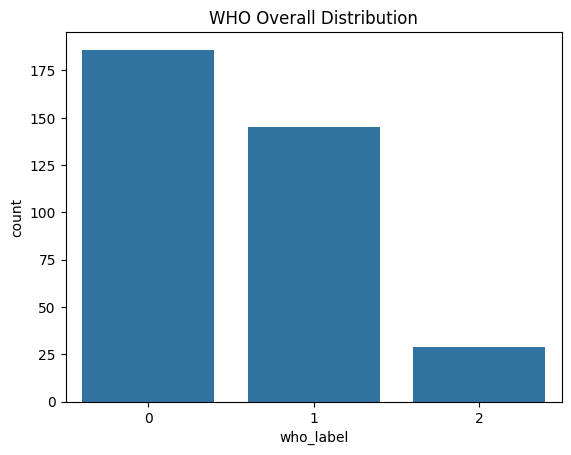

In [6]:
sns.countplot(x=df['who_label'])
plt.title("WHO Overall Distribution")

Text(0.5, 1.0, 'PSS Distribution')

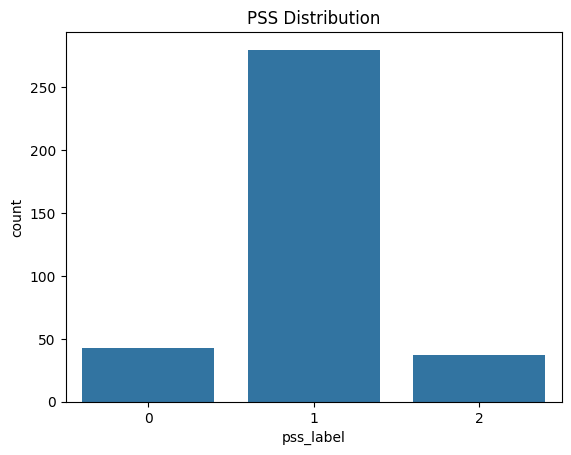

In [7]:
sns.countplot(x=df['pss_label'])
plt.title("PSS Distribution")

Text(0.5, 1.0, 'CDSIMER Label')

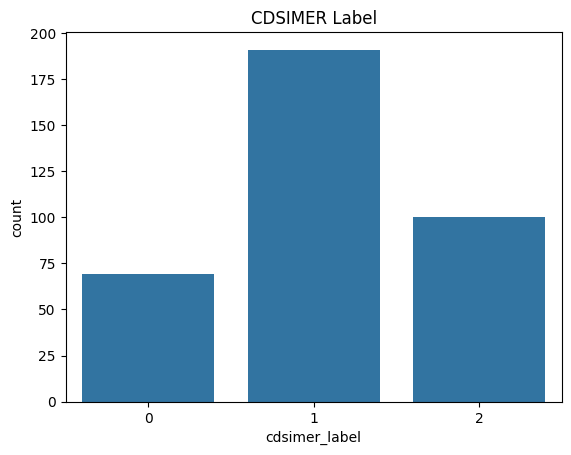

In [8]:
sns.countplot(x=df['cdsimer_label'])
plt.title("CDSIMER Label")

/var/folders/cm/45pwn7v57sg44tv1lz8359140000gn/T/ipykernel_1275/1614100070.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,6))


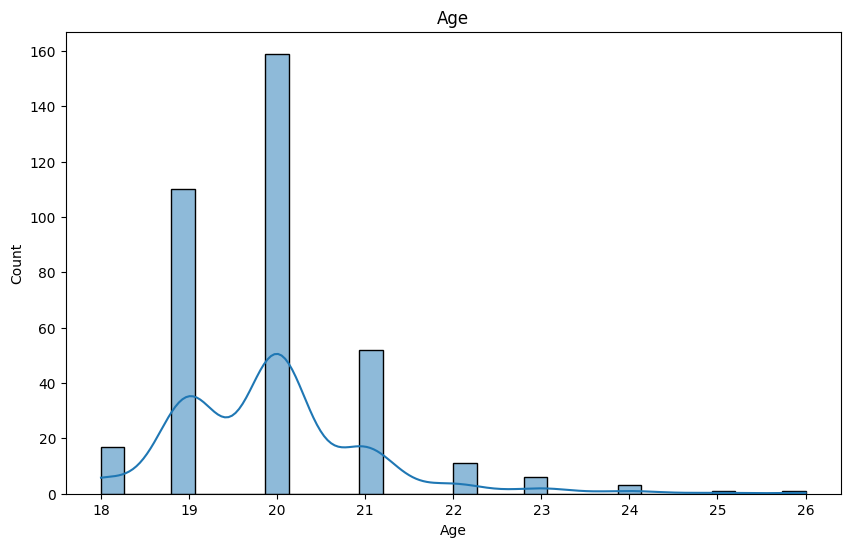

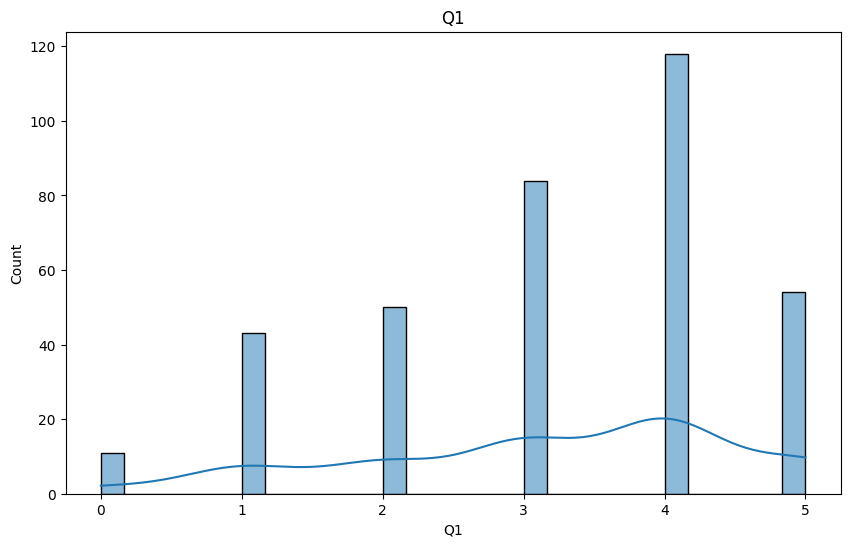

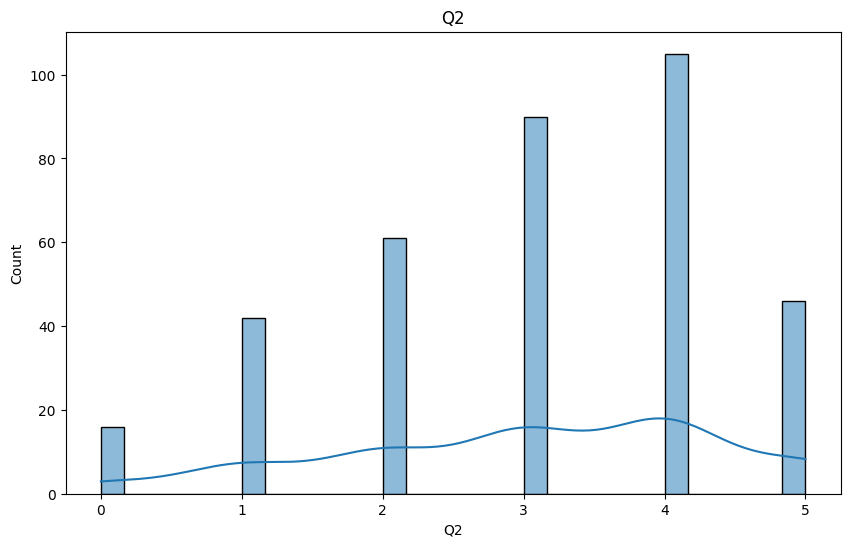

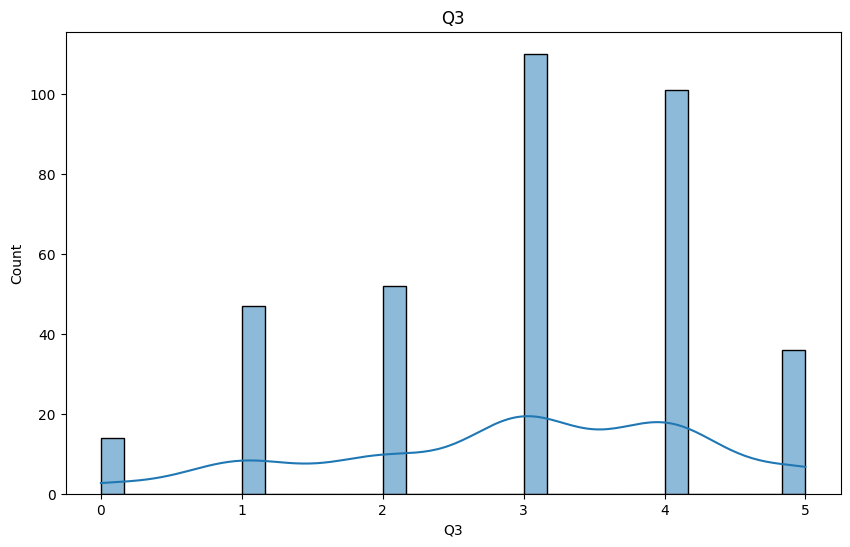

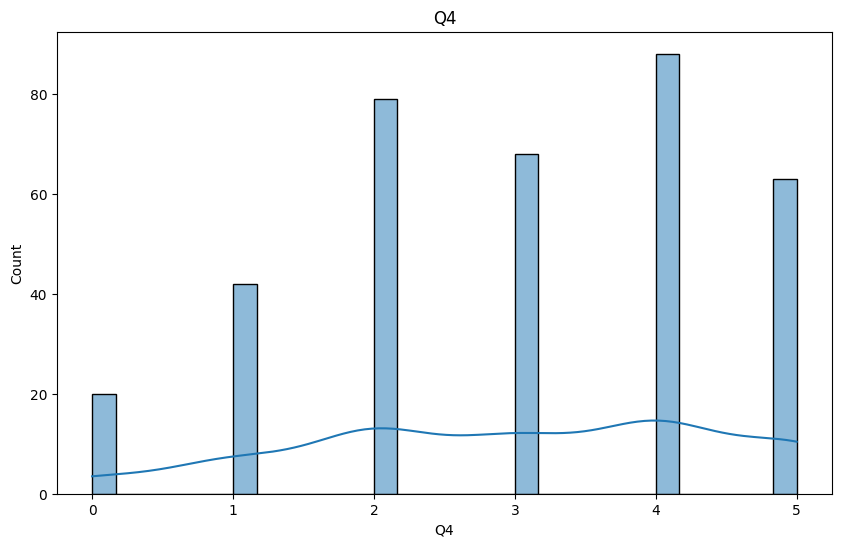

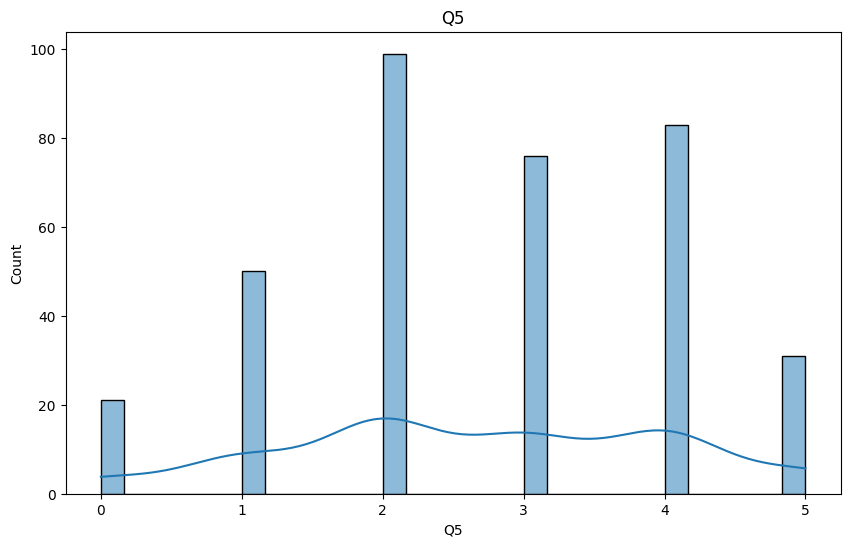

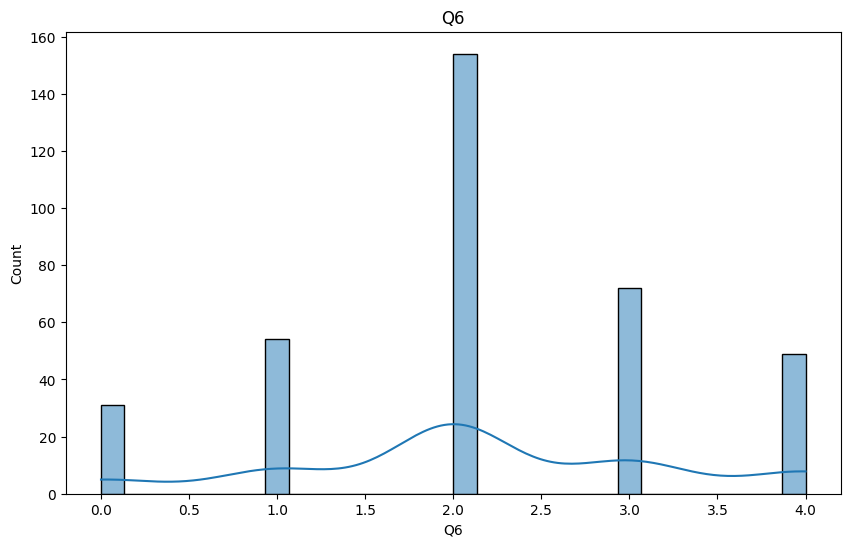

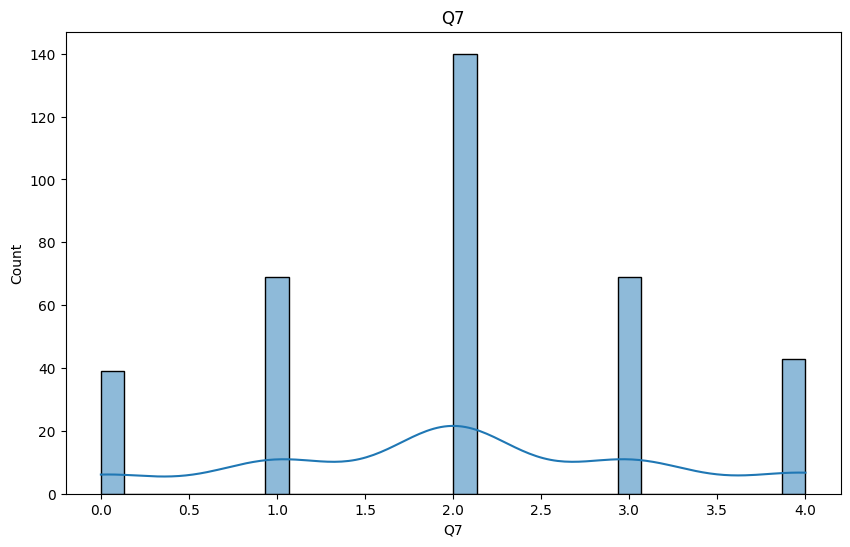

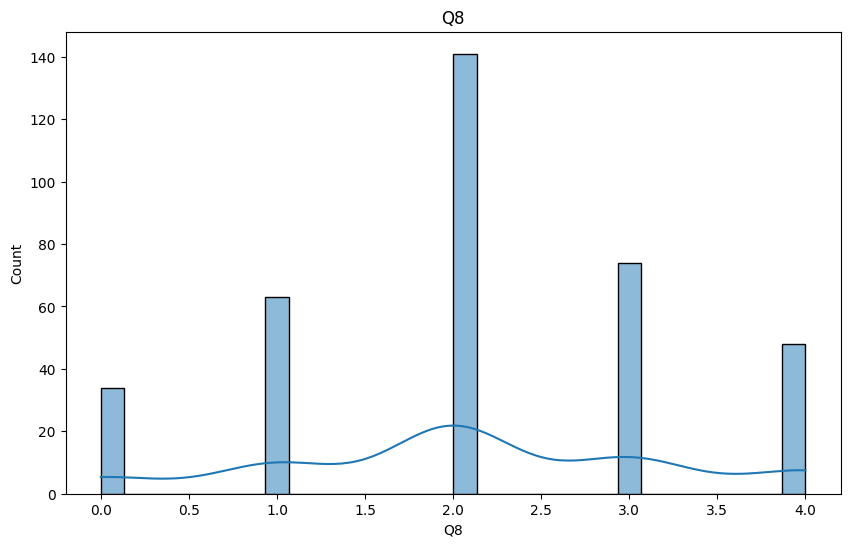

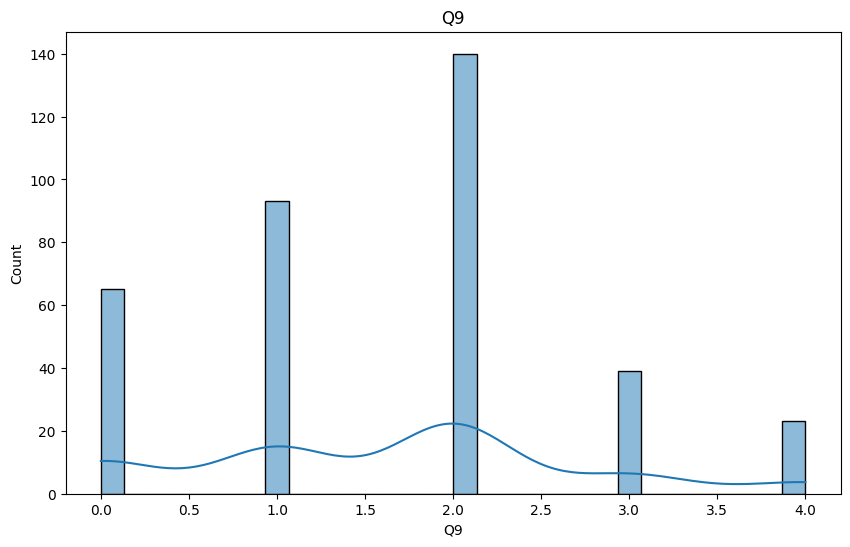

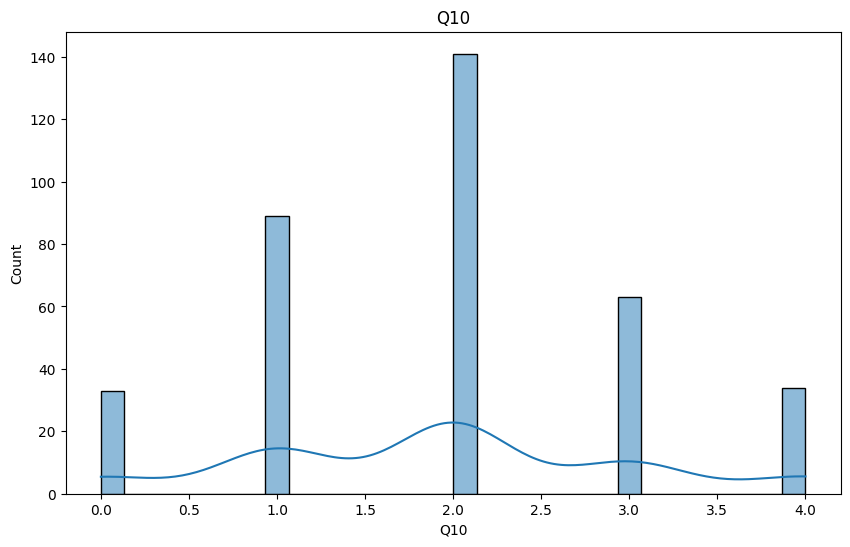

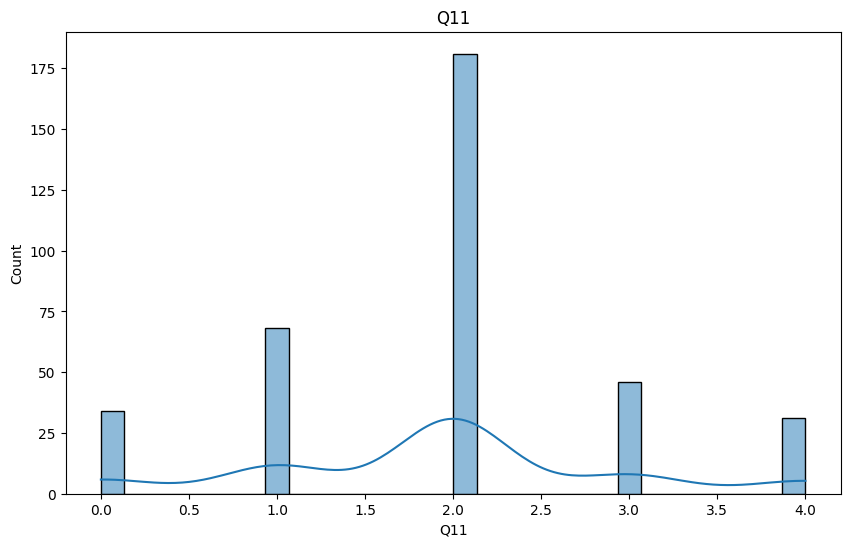

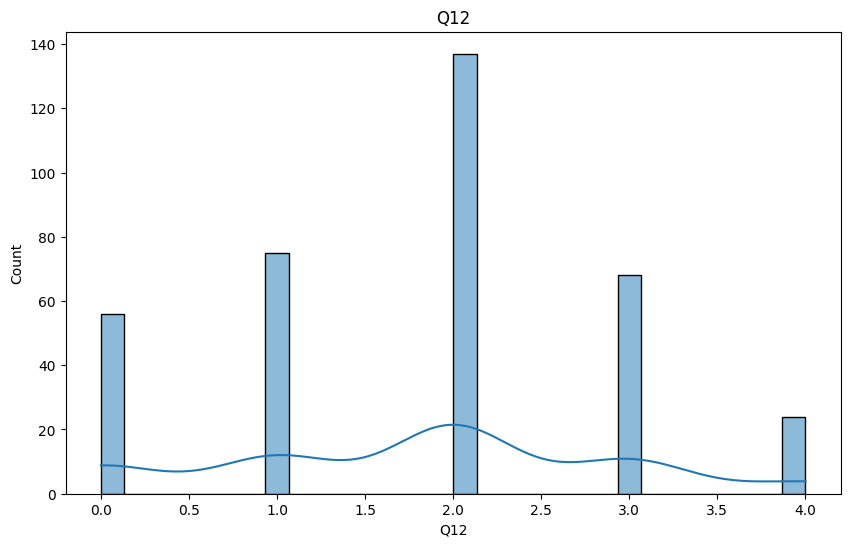

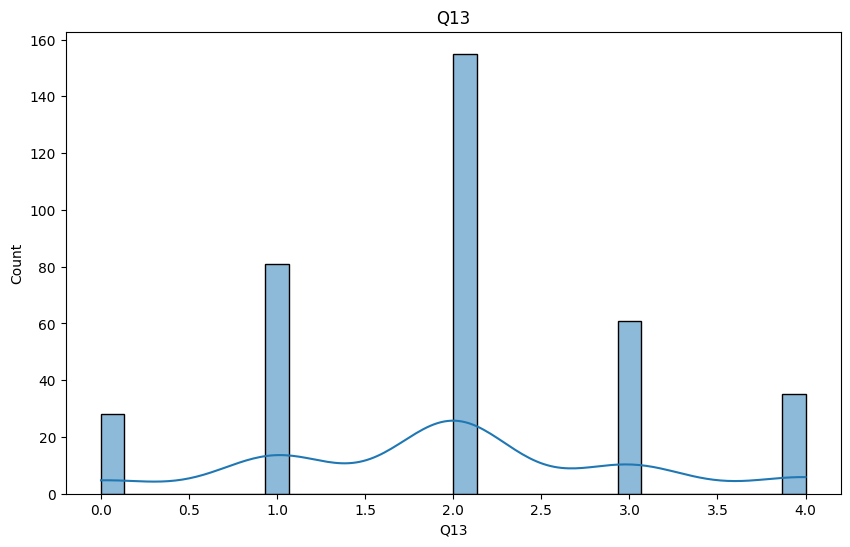

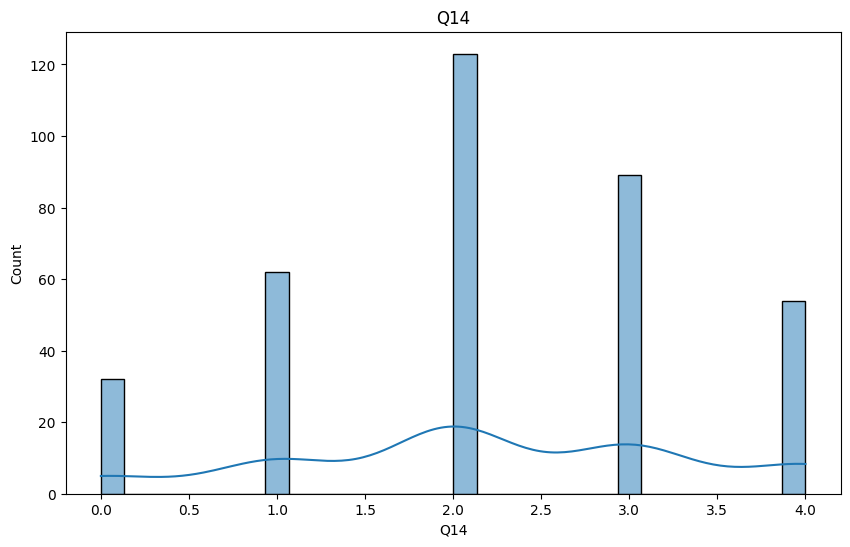

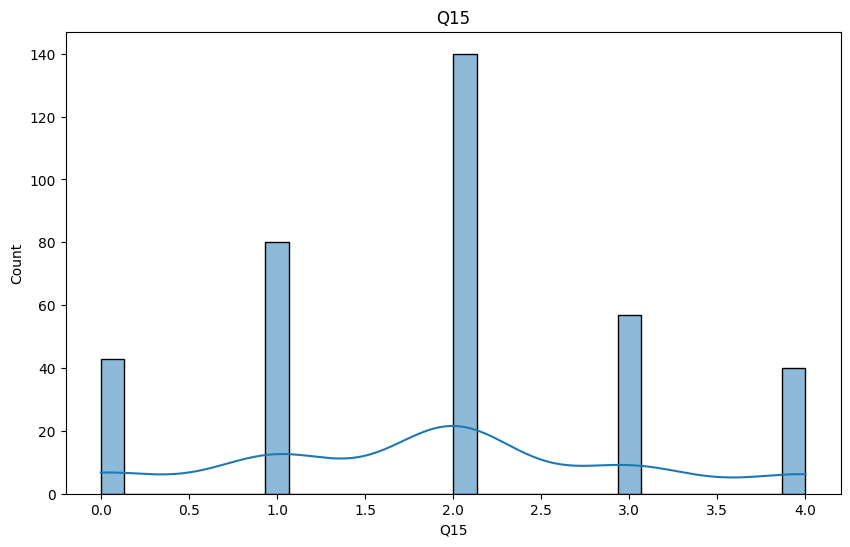

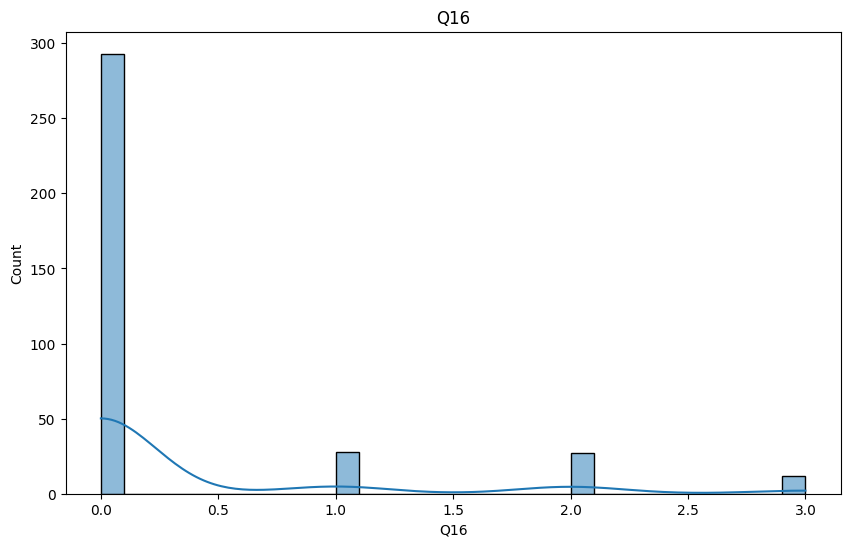

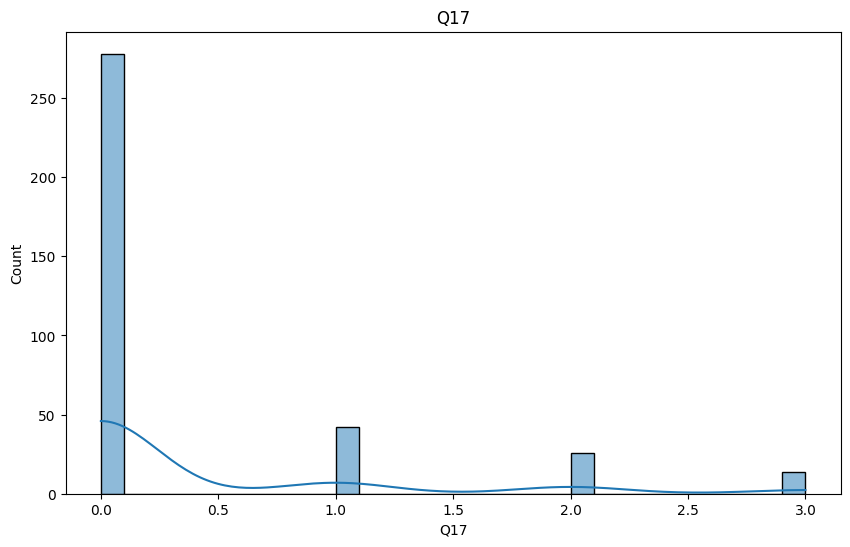

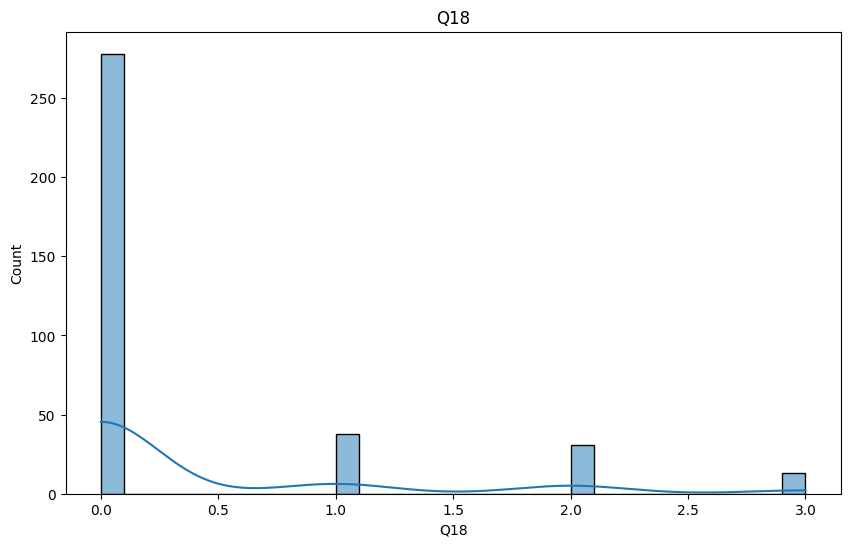

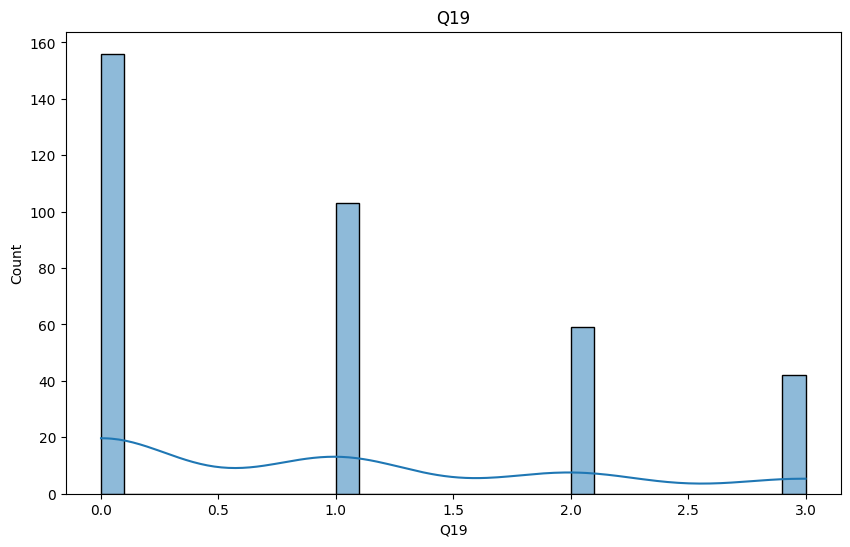

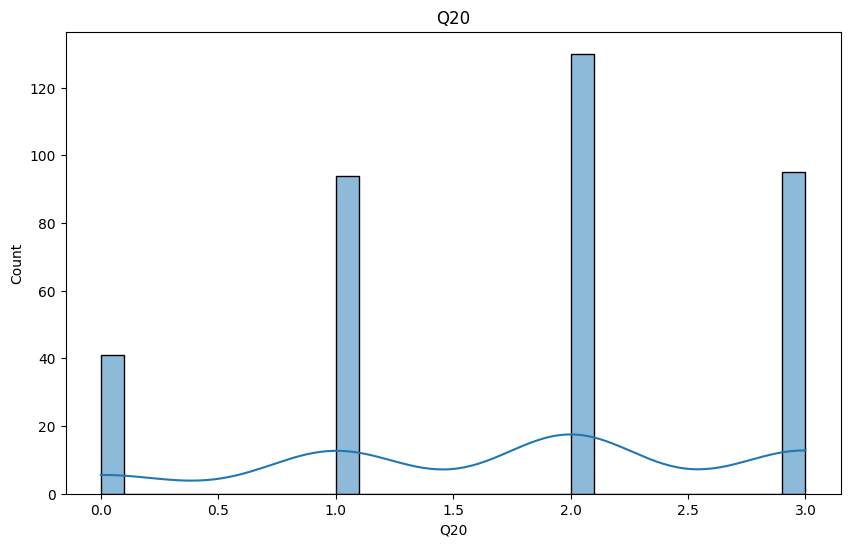

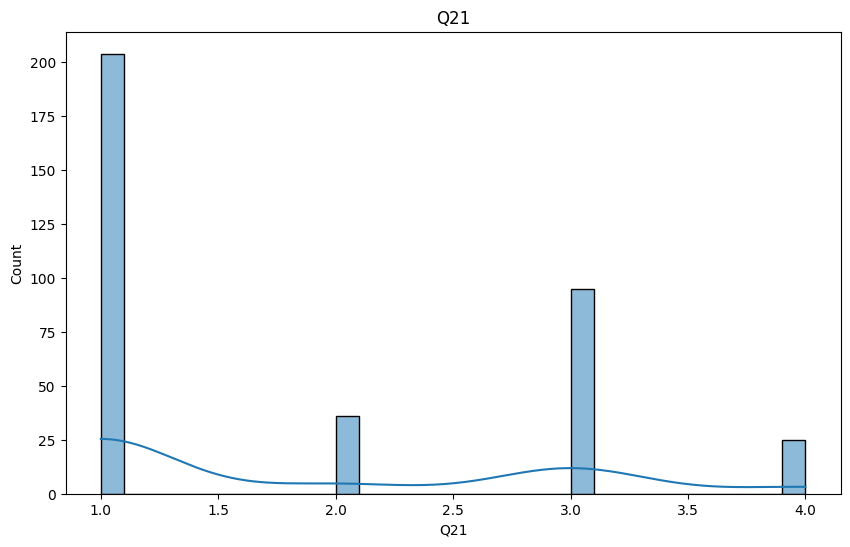

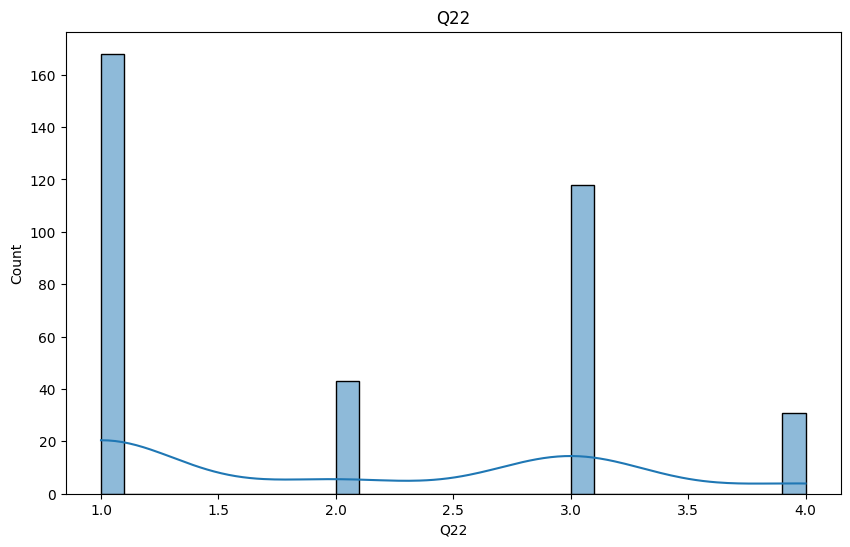

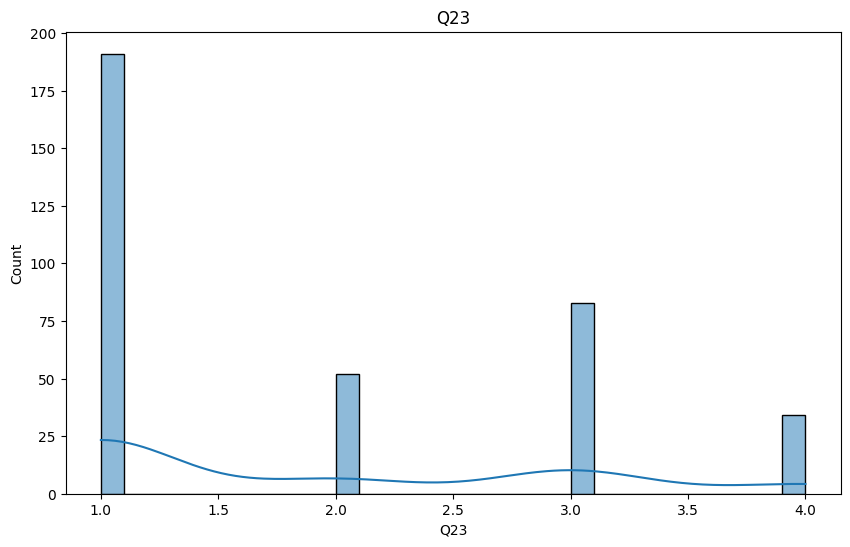

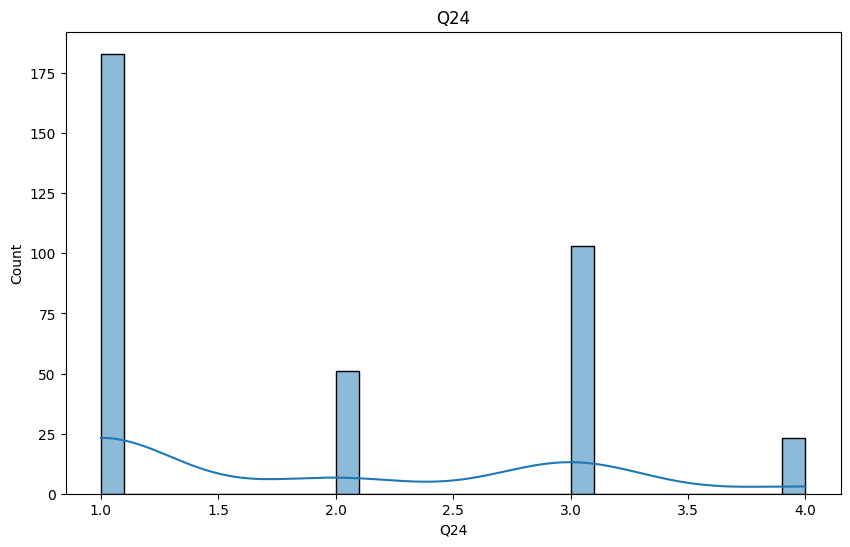

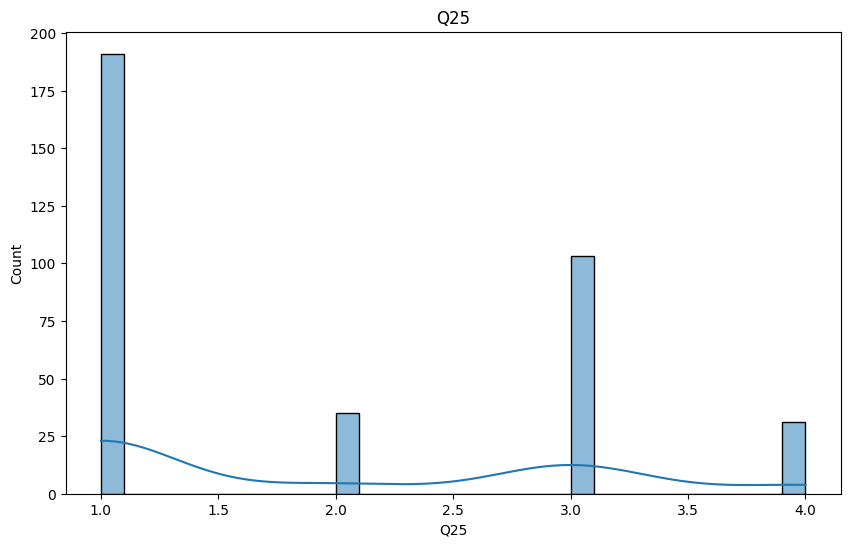

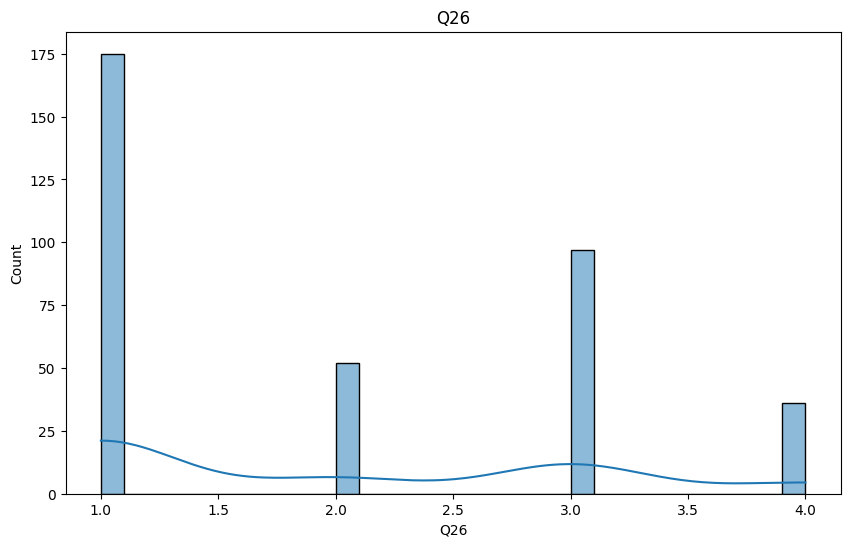

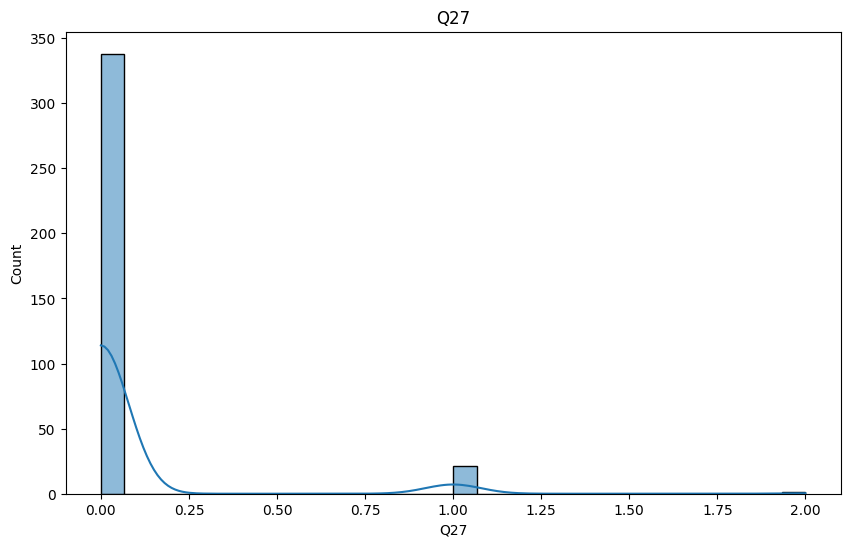

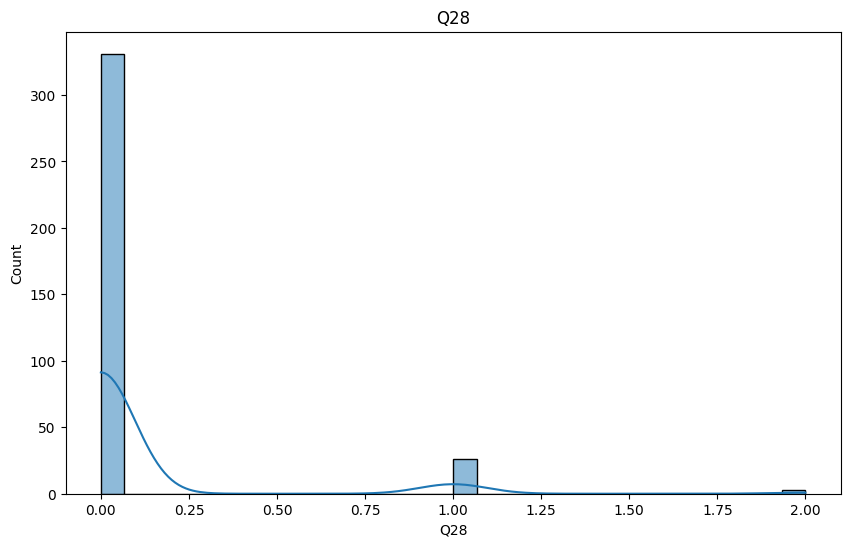

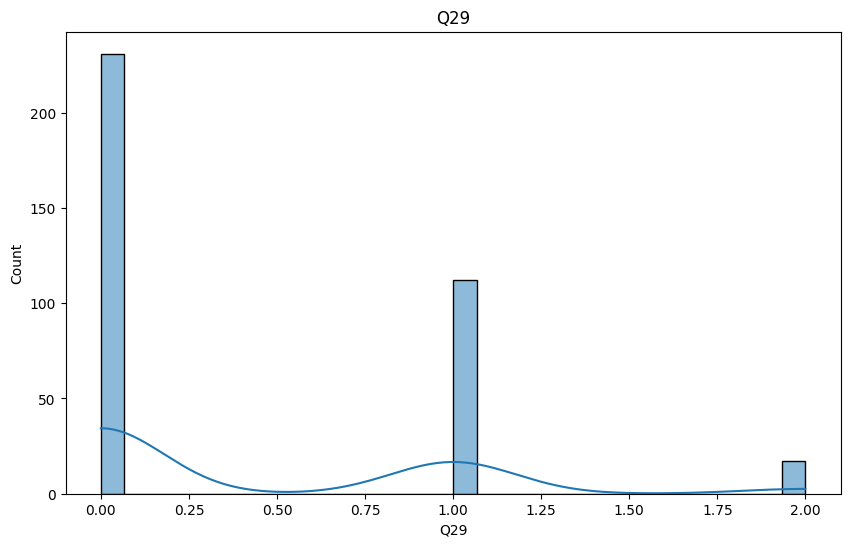

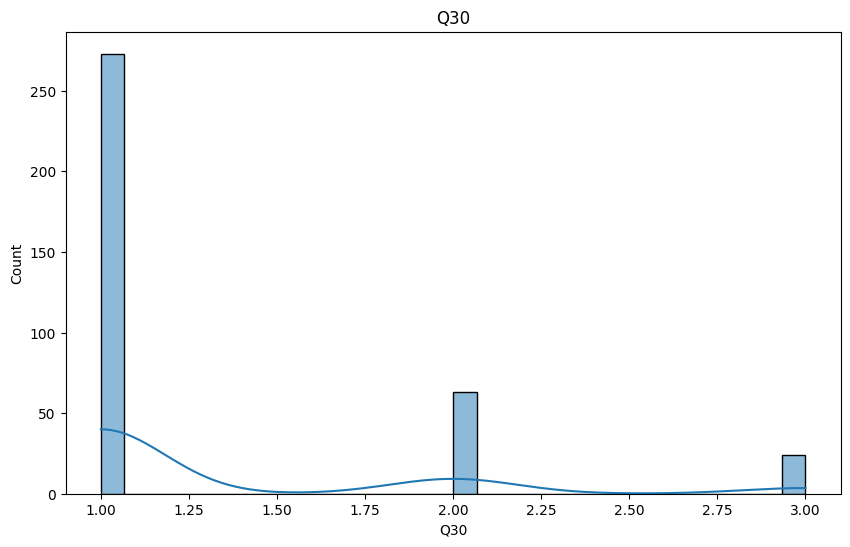

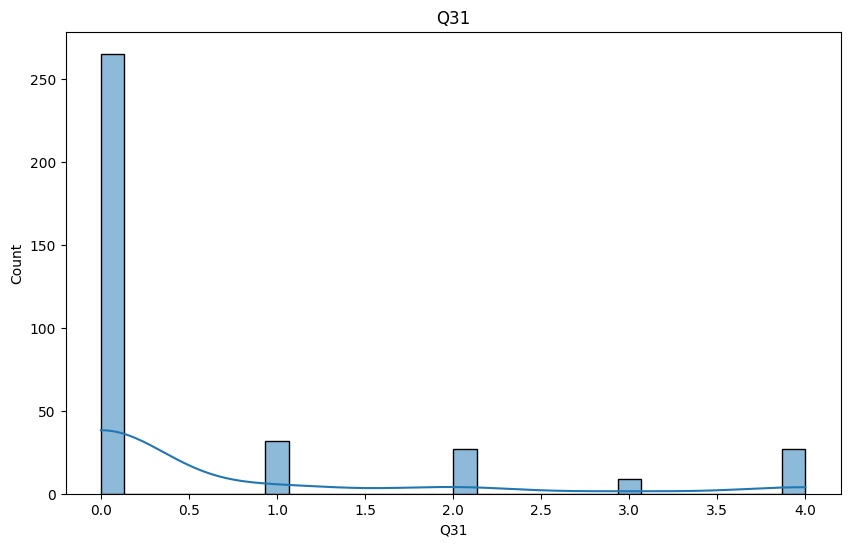

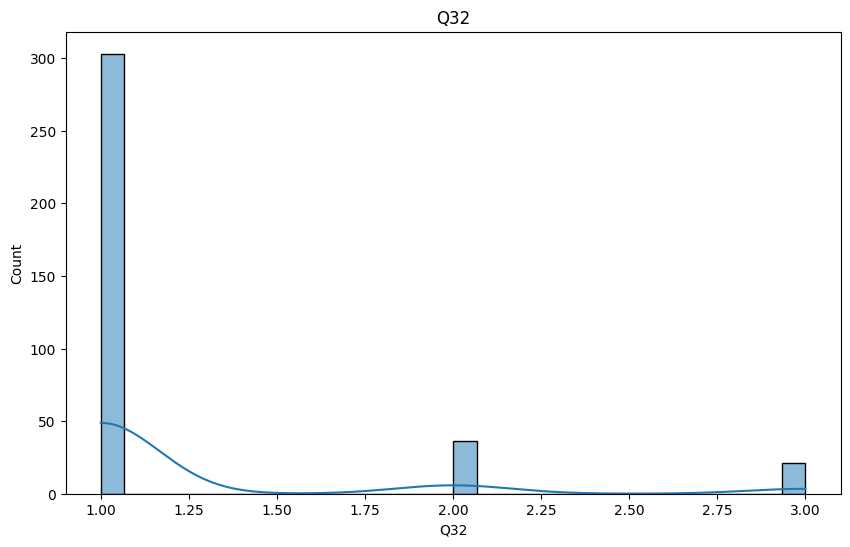

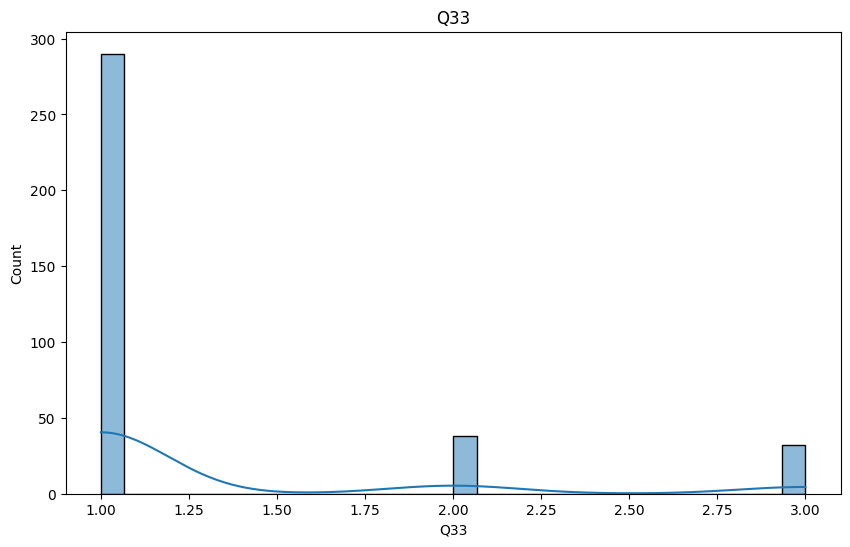

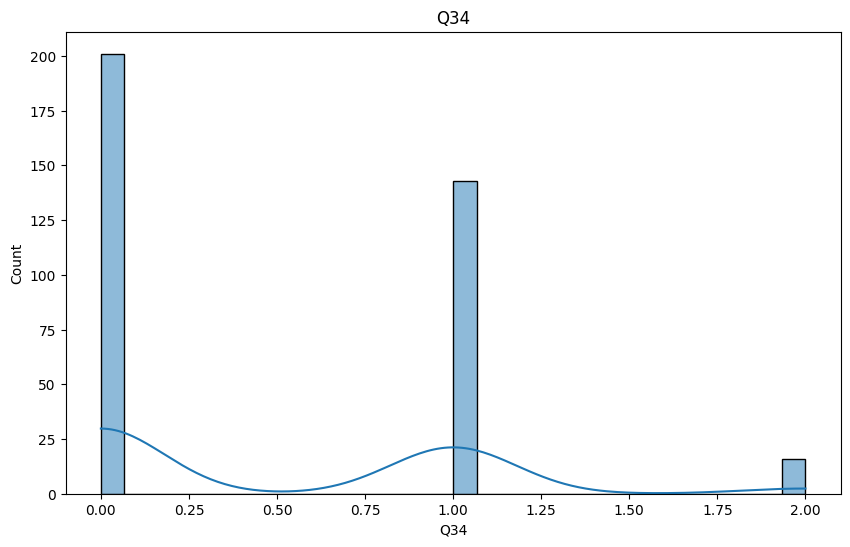

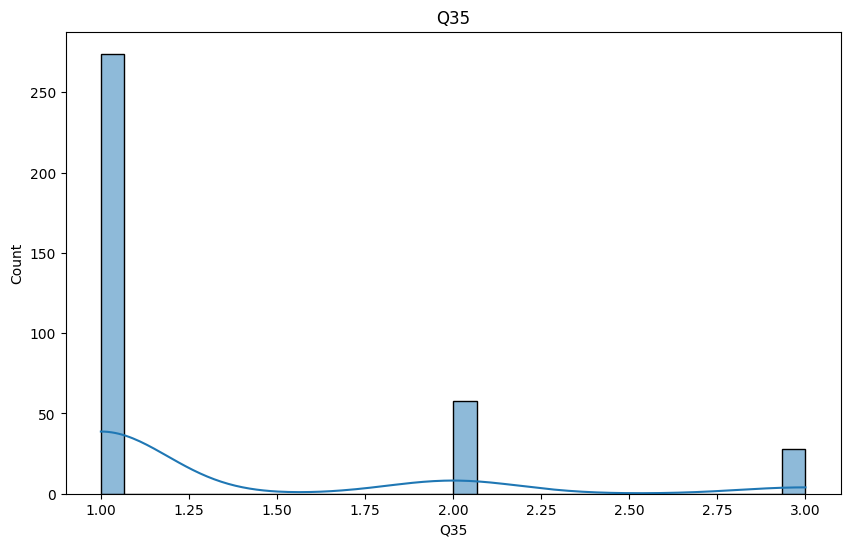

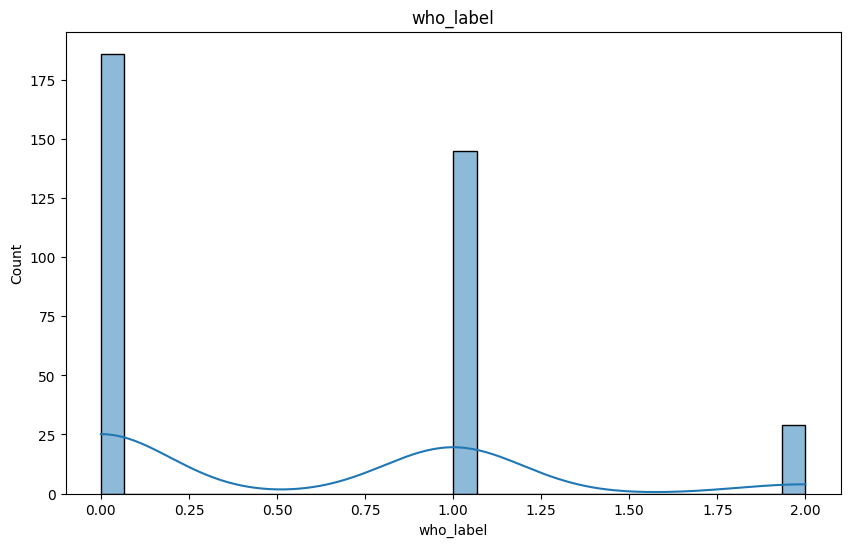

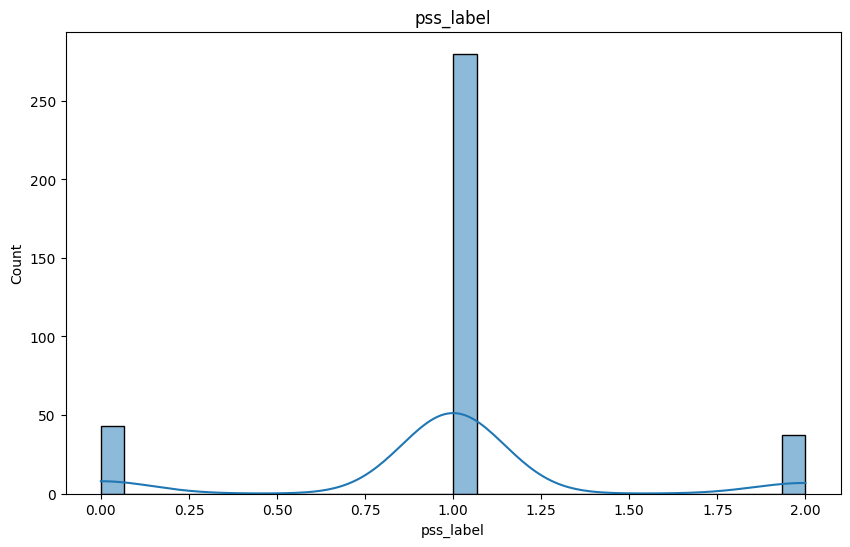

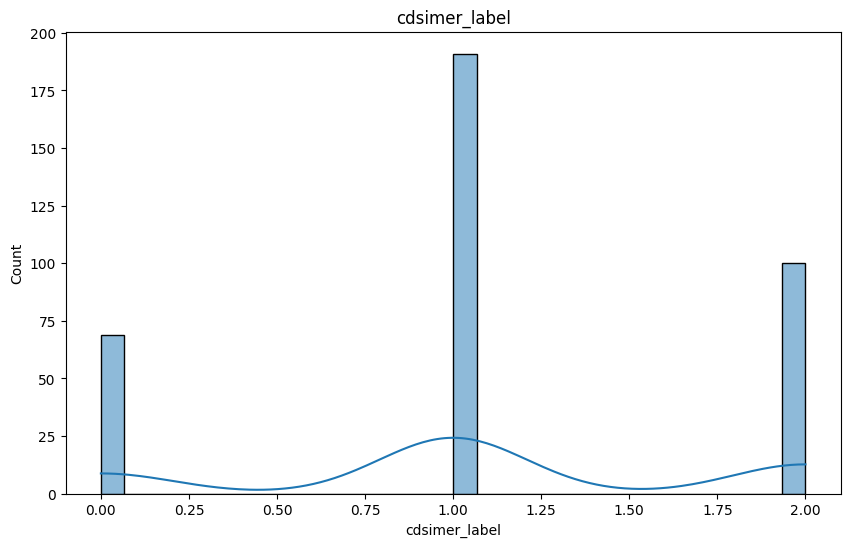

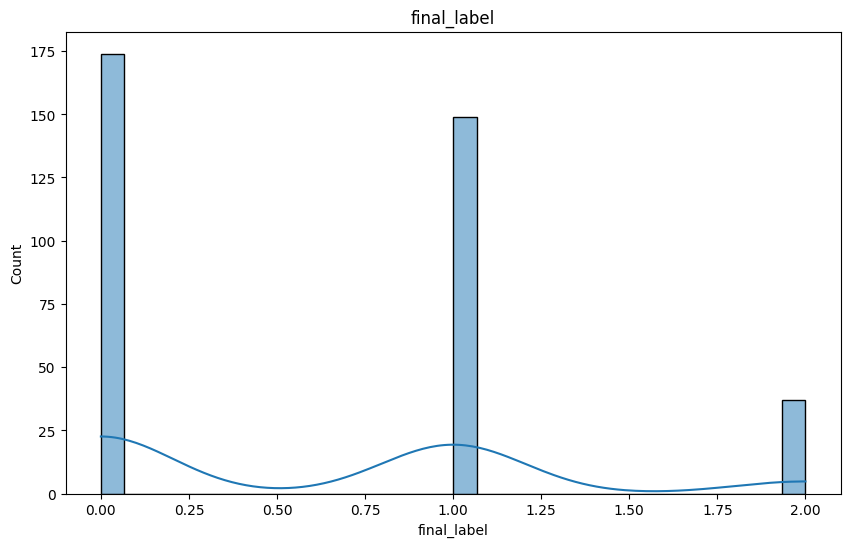

In [9]:
for col in df.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(x=df[col],bins=30,kde=True)
    plt.title(f"{col}")

In [10]:
cols = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']

filtered_df = df[(df[cols] == 4).any(axis=1)]

In [11]:
print(filtered_df['pss_label'].value_counts())
print(filtered_df['cdsimer_label'].value_counts())

pss_label
1    181
0     37
2     12
Name: count, dtype: int64
cdsimer_label
1    131
0     56
2     43
Name: count, dtype: int64


In [12]:
import pandas as pd

comparison = pd.crosstab(
    filtered_df['pss_label'],
    filtered_df['cdsimer_label']
)

print(comparison)

cdsimer_label   0    1   2
pss_label                 
0              12   24   1
1              44  103  34
2               0    4   8


In [13]:
for col in cols:
    temp = df[df[col] == 4]
    
    print(f"\n--- {col} ---")
    print(pd.crosstab(temp['pss_label'], temp['cdsimer_label']))


--- Q1 ---
cdsimer_label   0   1   2
pss_label                
0               7  17   1
1              21  53  13
2               0   3   3

--- Q2 ---
cdsimer_label   0   1   2
pss_label                
0               6  13   0
1              31  44  10
2               0   0   1

--- Q3 ---
cdsimer_label   0   1  2
pss_label               
0               6   8  0
1              26  46  8
2               0   3  4

--- Q4 ---
cdsimer_label   0   1   2
pss_label                
0               6   7   0
1              16  40  13
2               0   3   3

--- Q5 ---
cdsimer_label   0   1   2
pss_label                
0               6   9   1
1              26  28  10
2               0   1   2


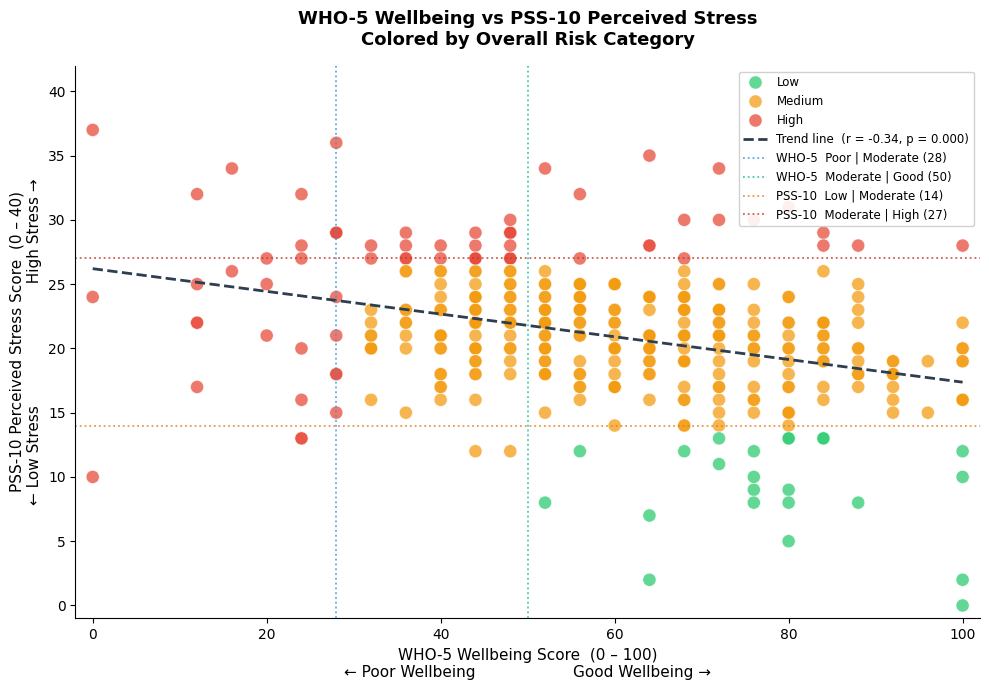

  CORRELATION SUMMARY
  Pearson   r = -0.343   p = 0.0000
  Spearman  r = -0.340   p = 0.0000

── Score Descriptives ────────────────────────
       WHO5_score  PSS10_score
count      360.00       360.00
mean        59.11        20.98
std         20.70         5.33
min          0.00         0.00
25%         44.00        18.00
50%         60.00        21.00
75%         72.00        24.00
max        100.00        37.00

── Risk Category Crosstab ────────────────────
PSS-10    Low  Moderate  High  All
WHO-5                             
Poor        3        15    11   29
Moderate    2        74    21   97
Good       23       195    16  234
All        28       284    48  360

── Overall Risk Distribution ─────────────────
Overall_risk
Low        23
Medium    271
High       66
Name: count, dtype: int64


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
df = pd.read_csv(r"/Users/anirudhiyer/Desktop/Stress Prediction/Minor-Project/Datasets/preprocessed.csv")

# ── 2. COLUMN SETUP ───────────────────────────────────────────────────────────
who5_cols  = ["Q1", "Q2", "Q3", "Q4", "Q5"]
pss10_cols = ["Q6", "Q7", "Q8", "Q9", "Q10", "Q11", "Q12", "Q13", "Q14", "Q15"]

# ── 3. SCORING ────────────────────────────────────────────────────────────────

# WHO-5: scored 0–5 per item → raw sum 0–25 → multiply by 4 → scale 0–100
# Higher = BETTER wellbeing (inversely related to stress)
df["WHO5_raw"]   = df[who5_cols].sum(axis=1)          # 0–25
df["WHO5_score"] = df["WHO5_raw"] * 4                 # 0–100

# PSS-10: scored 0–4 per item
# Reverse-scored items (positively worded): Q4,Q5,Q7,Q8 of PSS
# → mapped to your columns: Q9, Q10, Q12, Q13
pss_reverse_cols = ["Q9", "Q10", "Q12", "Q13"]
pss_forward_cols = ["Q6", "Q7", "Q8", "Q11", "Q14", "Q15"]

for col in pss_reverse_cols:
    df[col + "_r"] = 4 - df[col]                      # reverse on 0–4 scale

pss_scored_cols   = pss_forward_cols + [c + "_r" for c in pss_reverse_cols]
df["PSS10_score"] = df[pss_scored_cols].sum(axis=1)   # 0–40

# ── 4. RISK CATEGORIES ────────────────────────────────────────────────────────

# WHO-5 Wellbeing tiers (based on 0–100 scale)
# >50 = Good wellbeing | 28–50 = Moderate | ≤28 = Poor (likely depression screen)
df["WHO5_risk"] = pd.cut(
    df["WHO5_score"],
    bins=[-1, 28, 50, 100],
    labels=["Poor", "Moderate", "Good"]
)

# PSS-10 Stress tiers
# 0–13 = Low stress | 14–26 = Moderate | 27–40 = High stress
df["PSS10_risk"] = pd.cut(
    df["PSS10_score"],
    bins=[-1, 13, 26, 40],
    labels=["Low", "Moderate", "High"]
)

# Combined overall risk (worst of both scales drives the label)
def combined_risk(row):
    pss = row["PSS10_risk"]
    who = row["WHO5_risk"]
    if pss == "High"     or who == "Poor":     return "High"
    if pss == "Moderate" or who == "Moderate": return "Medium"
    return "Low"

df["Overall_risk"] = df.apply(combined_risk, axis=1)

# ── 5. SCATTER PLOT ───────────────────────────────────────────────────────────
palette     = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}
risk_order  = ["Low", "Medium", "High"]

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="WHO5_score",
    y="PSS10_score",
    hue="Overall_risk",
    hue_order=risk_order,
    palette=palette,
    alpha=0.75,
    s=90,
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

# ── Regression trend line ──────────────────────────────────────────────────
slope, intercept, r, p, _ = stats.linregress(df["WHO5_score"], df["PSS10_score"])
x_line = np.linspace(df["WHO5_score"].min(), df["WHO5_score"].max(), 300)
ax.plot(
    x_line, slope * x_line + intercept,
    color="#2c3e50", linewidth=2, linestyle="--",
    label=f"Trend line  (r = {r:.2f}, p = {p:.3f})"
)

# ── Reference threshold lines ──────────────────────────────────────────────
ax.axvline(28, color="#3498db", linestyle=":", linewidth=1.3, alpha=0.8,
           label="WHO-5  Poor | Moderate (28)")
ax.axvline(50, color="#1abc9c", linestyle=":", linewidth=1.3, alpha=0.8,
           label="WHO-5  Moderate | Good (50)")
ax.axhline(14, color="#e67e22", linestyle=":", linewidth=1.3, alpha=0.8,
           label="PSS-10  Low | Moderate (14)")
ax.axhline(27, color="#c0392b", linestyle=":", linewidth=1.3, alpha=0.8,
           label="PSS-10  Moderate | High (27)")

# ── Labels & styling ───────────────────────────────────────────────────────
ax.set_xlabel(
    "WHO-5 Wellbeing Score  (0 – 100)\n← Poor Wellbeing                    Good Wellbeing →",
    fontsize=11
)
ax.set_ylabel(
    "PSS-10 Perceived Stress Score  (0 – 40)\n← Low Stress                         High Stress →",
    fontsize=11
)
ax.set_title(
    "WHO-5 Wellbeing vs PSS-10 Perceived Stress\nColored by Overall Risk Category",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlim(-2, 102)
ax.set_ylim(-1, 42)
ax.legend(loc="upper right", fontsize=8.5, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.savefig("who5_vs_pss10_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6. PRINTED SUMMARY ────────────────────────────────────────────────────────
print("=" * 52)
print("  CORRELATION SUMMARY")
print("=" * 52)
pearson_r,  pearson_p  = stats.pearsonr(df["WHO5_score"], df["PSS10_score"])
spearman_r, spearman_p = stats.spearmanr(df["WHO5_score"], df["PSS10_score"])
print(f"  Pearson   r = {pearson_r:+.3f}   p = {pearson_p:.4f}")
print(f"  Spearman  r = {spearman_r:+.3f}   p = {spearman_p:.4f}")

print("\n── Score Descriptives ────────────────────────")
print(df[["WHO5_score", "PSS10_score"]].describe().round(2))

print("\n── Risk Category Crosstab ────────────────────")
print(pd.crosstab(df["WHO5_risk"], df["PSS10_risk"],
                  rownames=["WHO-5"], colnames=["PSS-10"], margins=True))

print("\n── Overall Risk Distribution ─────────────────")
print(df["Overall_risk"].value_counts().reindex(risk_order))

In [15]:
pip install matplotlib_venn

Note: you may need to restart the kernel to use updated packages.


   MULTI-SCALE HIGH-RISK FLAGGING REPORT
  Total students         : 360
  Flagged on 2+ scales   : 41  (11.4%)
  Flagged on ALL 3       : 13  (3.6%)

── Per-Scale High-Risk Count ─────────────────
  WHO-5 high    : 29 students
  PSS-10 high   : 37 students
  CD high       : 100 students

── Combination Breakdown (2+ flagged) ────────
              Count  count
        PSS-10 + CD     16
WHO-5 + PSS-10 + CD     13
         WHO-5 + CD     11
     WHO-5 + PSS-10      1

── Flagged Students (2+ scales) ──────────────
 student_id  who_label  pss_label  cdsimer_label  high_scale_count      flagged_scales        risk_tier
        157          2          2              2                 3 WHO-5 + PSS-10 + CD 🔴 Critical (3/3)
        323          2          2              2                 3 WHO-5 + PSS-10 + CD 🔴 Critical (3/3)
         14          2          2              2                 3 WHO-5 + PSS-10 + CD 🔴 Critical (3/3)
         12          2          2              2                 

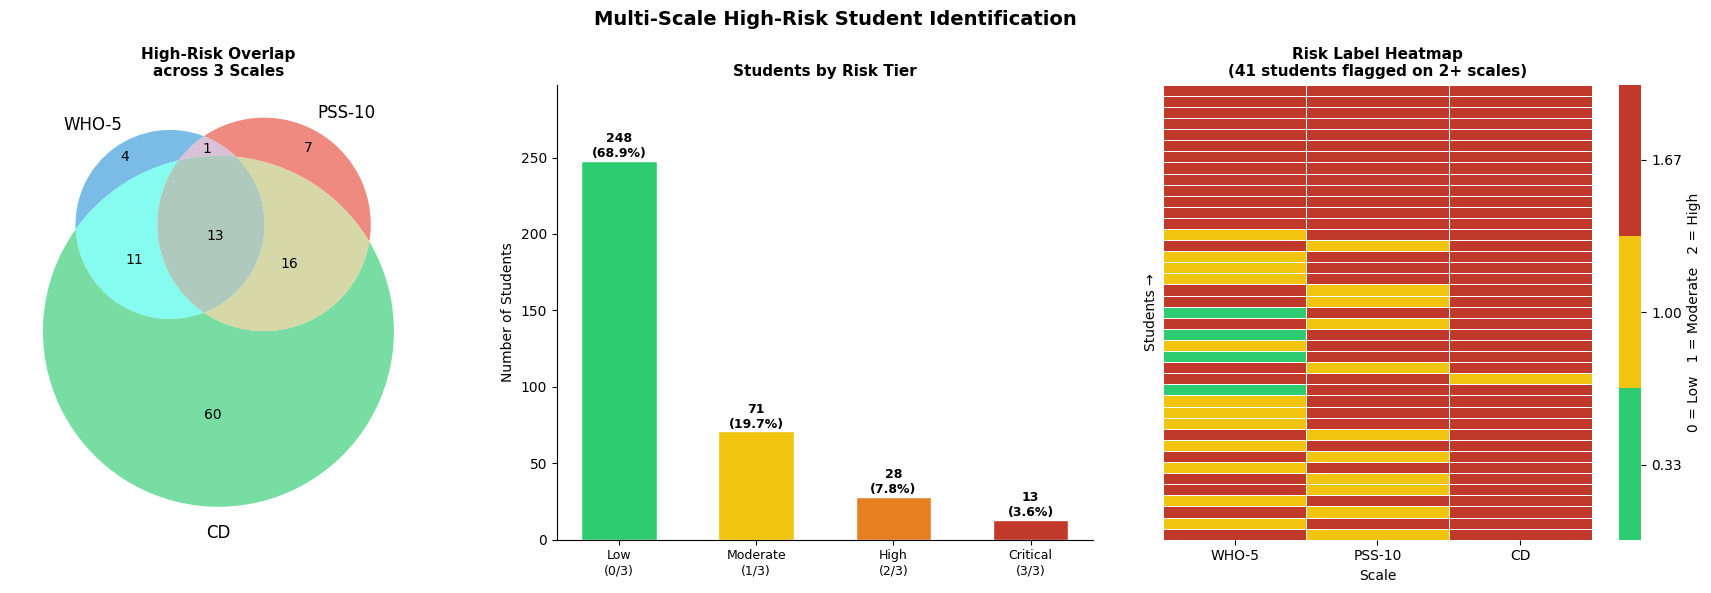

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3          # pip install matplotlib-venn




WHO_COL  = "who_label"        # 0=Low, 1=Moderate, 2=High
PSS_COL  = "pss_label"
CD_COL   = "cdsimer_label"
HIGH     = 2

# ── 3. BOOLEAN FLAGS ──────────────────────────────────────────────────────────
df["high_who"] = df[WHO_COL] == HIGH
df["high_pss"] = df[PSS_COL] == HIGH
df["high_cd"]  = df[CD_COL]  == HIGH

# ── 4. COUNT SCALES FLAGGED HIGH ──────────────────────────────────────────────
df["high_scale_count"] = df[["high_who", "high_pss", "high_cd"]].sum(axis=1)

# ── 5. FLAG STUDENTS ON 2+ SCALES ────────────────────────────────────────────
df["is_multirisk"] = df["high_scale_count"] >= 2

# Which specific scales flagged them
def flag_combo(row):
    scales = []
    if row["high_who"]: scales.append("WHO-5")
    if row["high_pss"]: scales.append("PSS-10")
    if row["high_cd"]:  scales.append("CD")
    return " + ".join(scales) if scales else "None"

df["flagged_scales"] = df.apply(flag_combo, axis=1)

# Severity tier
def risk_tier(n):
    if n == 3: return "🔴 Critical (3/3)"
    if n == 2: return "🟠 High (2/3)"
    if n == 1: return "🟡 Moderate (1/3)"
    return            "🟢 Low (0/3)"

df["risk_tier"] = df["high_scale_count"].apply(risk_tier)

# ── 6. SUMMARY ────────────────────────────────────────────────────────────────
total        = len(df)
multi_risk   = df[df["is_multirisk"]]
critical     = df[df["high_scale_count"] == 3]

print("=" * 52)
print("   MULTI-SCALE HIGH-RISK FLAGGING REPORT")
print("=" * 52)
print(f"  Total students         : {total}")
print(f"  Flagged on 2+ scales   : {len(multi_risk)}  ({len(multi_risk)/total*100:.1f}%)")
print(f"  Flagged on ALL 3       : {len(critical)}  ({len(critical)/total*100:.1f}%)")

print("\n── Per-Scale High-Risk Count ─────────────────")
print(f"  WHO-5 high    : {df['high_who'].sum()} students")
print(f"  PSS-10 high   : {df['high_pss'].sum()} students")
print(f"  CD high       : {df['high_cd'].sum()} students")

print("\n── Combination Breakdown (2+ flagged) ────────")
combo_counts = (multi_risk["flagged_scales"]
                .value_counts()
                .reset_index()
                .rename(columns={"index": "Combination", "flagged_scales": "Count"}))
print(combo_counts.to_string(index=False))

# ── 7. FLAGGED STUDENT TABLE ──────────────────────────────────────────────────
flagged_df = (df[df["is_multirisk"]]
              [[WHO_COL, PSS_COL, CD_COL,
                "high_scale_count", "flagged_scales", "risk_tier"]]
              .sort_values("high_scale_count", ascending=False)
              .reset_index()
              .rename(columns={"index": "student_id"}))

print(f"\n── Flagged Students (2+ scales) ──────────────")
print(flagged_df.to_string(index=False))

# ── 8. VISUALISATIONS ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Multi-Scale High-Risk Student Identification",
             fontsize=14, fontweight="bold")

# ── Plot 1: Venn Diagram ──────────────────────────────────────────────────────
set_who = set(df.index[df["high_who"]])
set_pss = set(df.index[df["high_pss"]])
set_cd  = set(df.index[df["high_cd"]])

venn3(
    [set_who, set_pss, set_cd],
    set_labels=("WHO-5", "PSS-10", "CD"),
    set_colors=("#3498db", "#e74c3c", "#2ecc71"),
    alpha=0.65,
    ax=axes[0]
)
axes[0].set_title("High-Risk Overlap\nacross 3 Scales",
                  fontsize=11, fontweight="bold")

# ── Plot 2: Bar chart — tier distribution ─────────────────────────────────────
tier_order  = ["🟢 Low (0/3)", "🟡 Moderate (1/3)",
               "🟠 High (2/3)", "🔴 Critical (3/3)"]
tier_colors = ["#2ecc71", "#f1c40f", "#e67e22", "#c0392b"]
tier_counts = df["risk_tier"].value_counts().reindex(tier_order, fill_value=0)

bars = axes[1].bar(range(len(tier_order)), tier_counts.values,
                   color=tier_colors, edgecolor="white", width=0.55)

for i, (bar, val) in enumerate(zip(bars, tier_counts.values)):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{val}\n({val/total*100:.1f}%)",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")

axes[1].set_xticks(range(len(tier_order)))
axes[1].set_xticklabels(["Low\n(0/3)", "Moderate\n(1/3)",
                          "High\n(2/3)", "Critical\n(3/3)"], fontsize=9)
axes[1].set_ylabel("Number of Students")
axes[1].set_title("Students by Risk Tier",
                  fontsize=11, fontweight="bold")
axes[1].set_ylim(0, tier_counts.max() * 1.2)
sns.despine(ax=axes[1])

# ── Plot 3: Heatmap of flagged students ───────────────────────────────────────
hmap_data = (df[df["is_multirisk"]]
             .sort_values("high_scale_count", ascending=False)
             [[WHO_COL, PSS_COL, CD_COL]])
hmap_data.columns = ["WHO-5", "PSS-10", "CD"]

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#2ecc71", "#f1c40f", "#c0392b"])  # 0=green,1=yellow,2=red

sns.heatmap(
    hmap_data,
    ax=axes[2],
    cmap=cmap,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"ticks": [0.33, 1.0, 1.67],
              "label": "0 = Low   1 = Moderate   2 = High"},
    vmin=0, vmax=2,
    yticklabels=False
)
axes[2].set_title(f"Risk Label Heatmap\n({len(hmap_data)} students flagged on 2+ scales)",
                  fontsize=11, fontweight="bold")
axes[2].set_xlabel("Scale")
axes[2].set_ylabel("Students →")

plt.tight_layout()
plt.savefig("multirisk_flagged_students.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap                              # pip install umap-learn
from scipy.stats import pearsonr

/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/run

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/

AttributeError: _ARRAY_API not found

ImportError: numpy.core._multiarray_umath failed to import

In [19]:
who5_cols  = [f"Q{i}" for i in range(1, 6)]       # Q1–Q5
pss10_cols = [f"Q{i}" for i in range(6, 16)]       # Q6–Q15
cd_cols    = [f"Q{i}" for i in range(16, 36)]      # Q16–Q35

all_q_cols = who5_cols + pss10_cols + cd_cols

# Risk labels (0=Low, 1=Moderate, 2=High)
WHO_COL = "who_label"
PSS_COL = "pss_label"
CD_COL  = "cdsimer_label"

/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposi

Components needed for 80% variance: 19

── PCA Variance per Component ───────────────────
  PC1:  21.7%  (cumul  21.7%)  ██████████
  PC2:   7.6%  (cumul  29.3%)  ███
  PC3:   5.4%  (cumul  34.7%)  ██
  PC4:   4.8%  (cumul  39.5%)  ██
  PC5:   4.2%  (cumul  43.7%)  ██
  PC6:   3.7%  (cumul  47.4%)  █
  PC7:   3.5%  (cumul  50.8%)  █
  PC8:   3.4%  (cumul  54.2%)  █


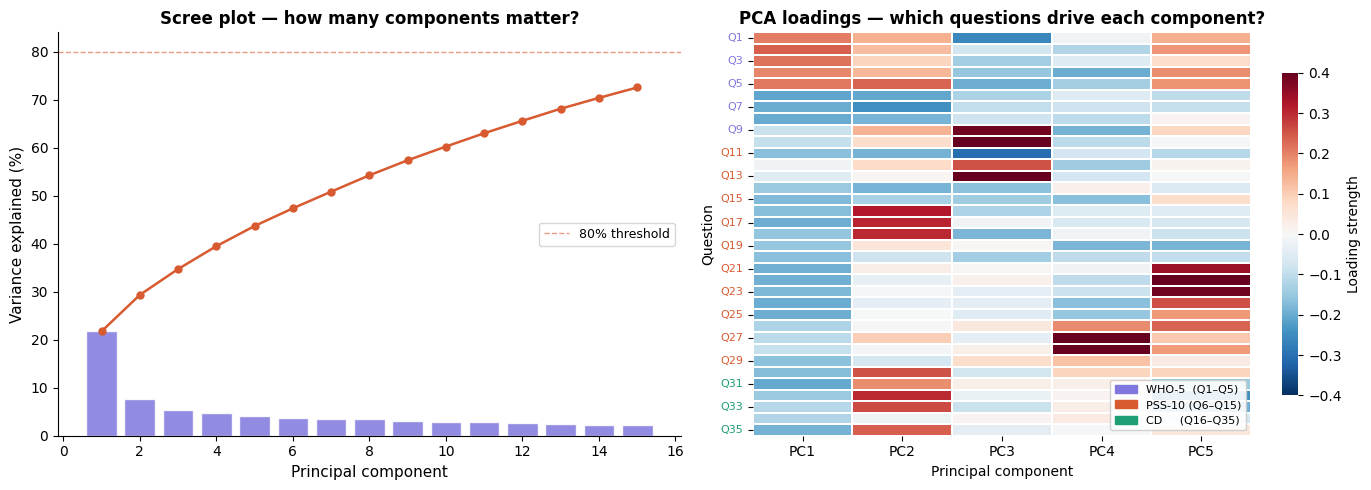


── Top 5 questions loading on each PC ───────────

  PC1:
    +Q2 (WHO-5)  loading = 0.240
    +Q3 (WHO-5)  loading = 0.216
    +Q5 (WHO-5)  loading = 0.211
    -Q6 (PSS-10)  loading = 0.210
    +Q1 (WHO-5)  loading = 0.205

  PC2:
    +Q16 (CD)  loading = 0.320
    +Q17 (CD)  loading = 0.306
    +Q18 (CD)  loading = 0.301
    +Q32 (CD)  loading = 0.301
    +Q33 (CD)  loading = 0.262

  PC3:
    +Q13 (PSS-10)  loading = 0.429
    +Q10 (PSS-10)  loading = 0.411
    +Q9 (PSS-10)  loading = 0.388
    -Q11 (PSS-10)  loading = 0.305
    -Q1 (WHO-5)  loading = 0.262

  PC4:
    +Q28 (CD)  loading = 0.577
    +Q27 (CD)  loading = 0.532
    -Q4 (WHO-5)  loading = 0.199
    +Q26 (CD)  loading = 0.190
    -Q9 (PSS-10)  loading = 0.188

  PC5:
    +Q22 (CD)  loading = 0.413
    +Q23 (CD)  loading = 0.390
    +Q21 (CD)  loading = 0.344
    +Q24 (CD)  loading = 0.257
    -Q32 (CD)  loading = 0.246


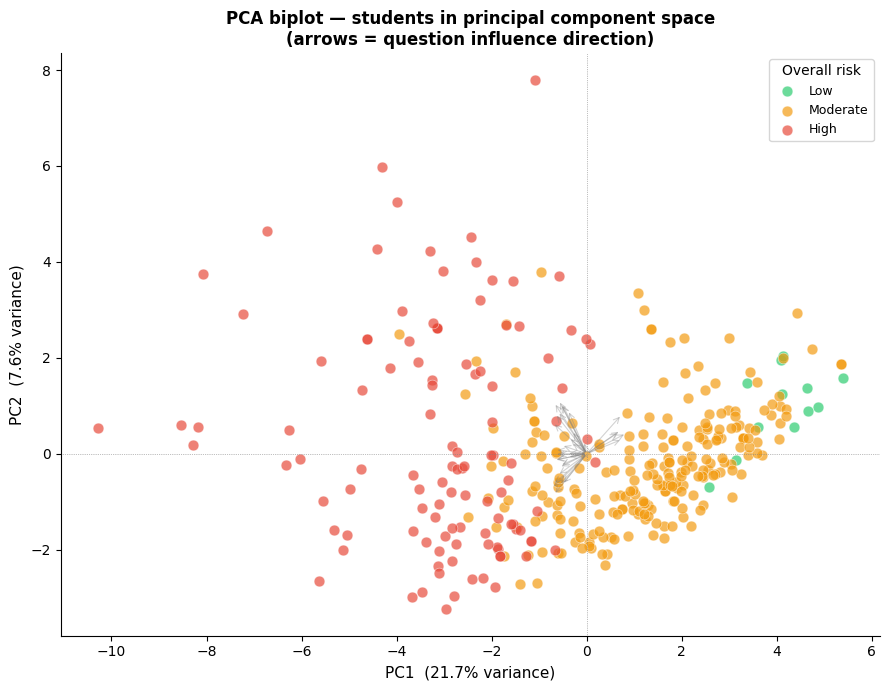


── PC1 correlation with risk labels ─────────────
  PC1 vs who_label: r = -0.693  (p = 0.0000)
  PC1 vs pss_label: r = -0.622  (p = 0.0000)
  PC1 vs cdsimer_label: r = -0.742  (p = 0.0000)


/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


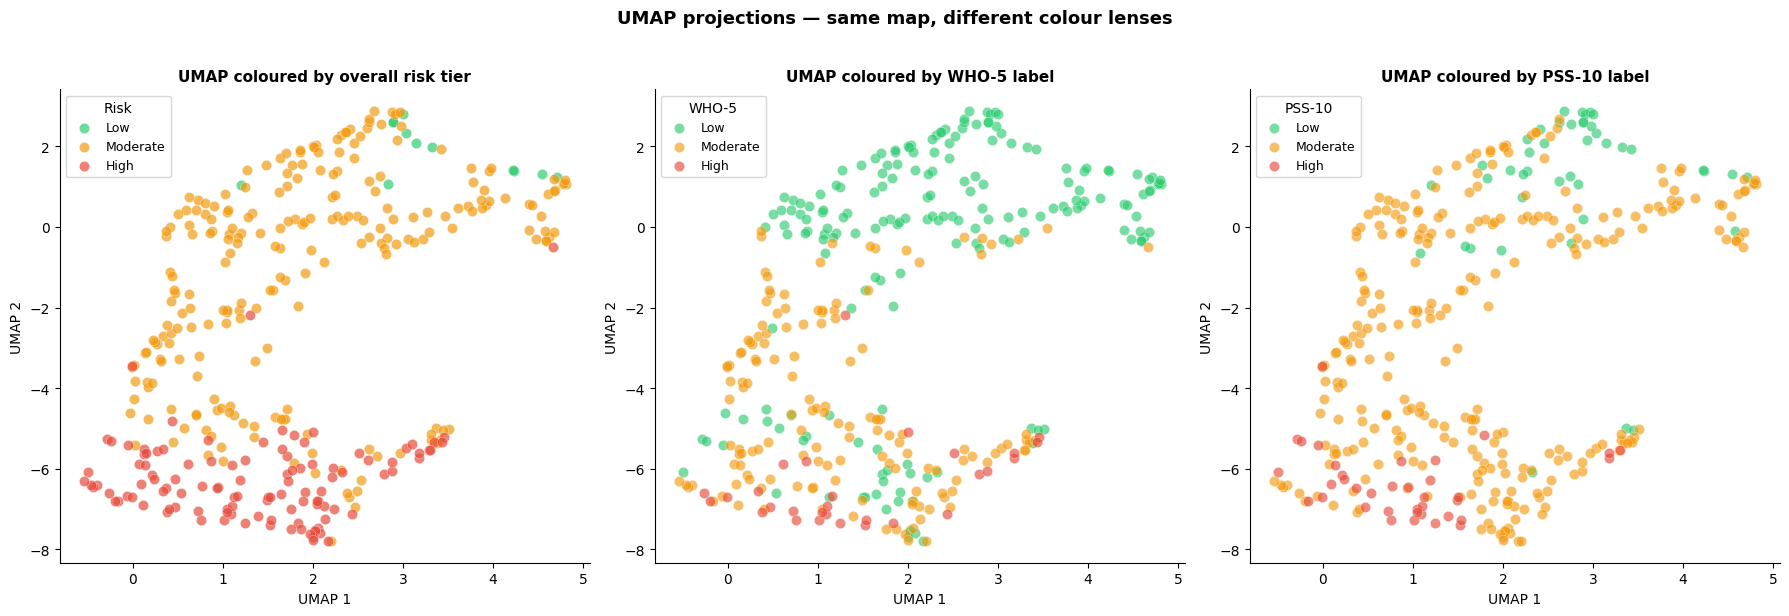

/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


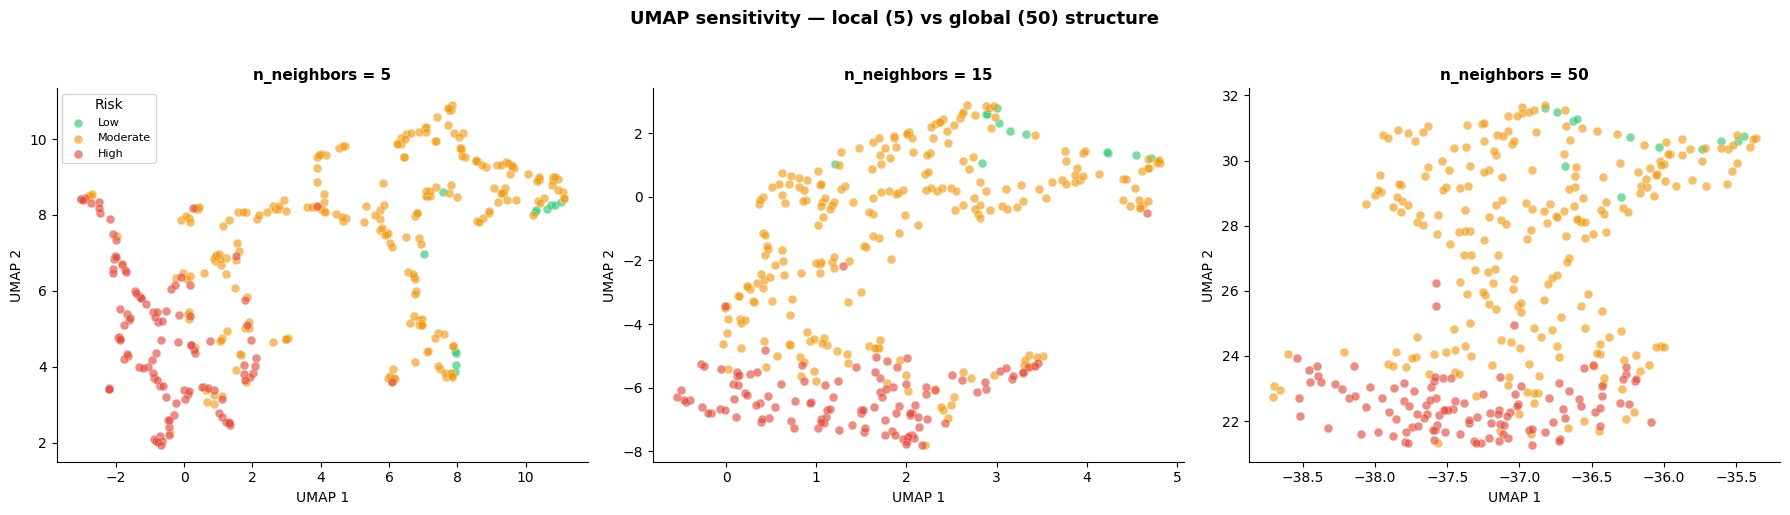


── UMAP cluster region composition ──────────────
overall_risk   High   Low  Moderate
umap_quadrant                      
0              0.57  0.00      0.43
1              0.01  0.01      0.97
2              0.69  0.00      0.31
3              0.01  0.10      0.89

── Students per risk tier in UMAP space ─────────
overall_risk
Low          12
Moderate    236
High        112
Name: count, dtype: int64


In [20]:
# Combined overall risk for colouring
def overall_risk(row):
    worst = max(row[WHO_COL], row[PSS_COL], row[CD_COL])
    return {0: "Low", 1: "Moderate", 2: "High"}[worst]

df["overall_risk"] = df.apply(overall_risk, axis=1)
risk_palette = {"Low": "#2ecc71", "Moderate": "#f39c12", "High": "#e74c3c"}
risk_order   = ["Low", "Moderate", "High"]


X      = df[all_q_cols].dropna()
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)
idx    = X.index                         



pca_full   = PCA()
pca_full.fit(X_sc)
cum_var    = np.cumsum(pca_full.explained_variance_ratio_) * 100

# How many components to explain 80% variance?
n_80 = np.argmax(cum_var >= 80) + 1
print(f"Components needed for 80% variance: {n_80}")

# Fit final PCA with chosen n
pca   = PCA(n_components=min(n_80, 5))
X_pca = pca.fit_transform(X_sc)

# ── A1: Scree + cumulative variance plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (first 15 components)
n_show = min(15, len(pca_full.explained_variance_ratio_))
axes[0].bar(range(1, n_show+1),
            pca_full.explained_variance_ratio_[:n_show] * 100,
            color="#7F77DD", edgecolor="white", alpha=0.85)
axes[0].plot(range(1, n_show+1),
             cum_var[:n_show], "o-", color="#D85A30", linewidth=1.8, markersize=5)
axes[0].axhline(80, color="#D85A30", linestyle="--", linewidth=1, alpha=0.6,
                label="80% threshold")
axes[0].set_xlabel("Principal component", fontsize=11)
axes[0].set_ylabel("Variance explained (%)", fontsize=11)
axes[0].set_title("Scree plot — how many components matter?",
                  fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# ── INSIGHT PRINT: scree ──────────────────────────────────────────────────────
print("\n── PCA Variance per Component ───────────────────")
for i, ev in enumerate(pca_full.explained_variance_ratio_[:8], 1):
    cum = cum_var[i-1]
    bar = "█" * int(ev * 100 / 2)
    print(f"  PC{i}: {ev*100:5.1f}%  (cumul {cum:5.1f}%)  {bar}")

# ── A2: Loadings heatmap ──────────────────────────────────────────────────────
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=all_q_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Colour-code question groups for y-axis
group_colors = (["#7F77DD"] * len(who5_cols) +
                ["#D85A30"] * len(pss10_cols) +
                ["#1D9E75"] * len(cd_cols))

sns.heatmap(
    loadings_df,
    ax=axes[1],
    cmap="RdBu_r",
    center=0,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Loading strength", "shrink": 0.8},
    vmin=-0.4, vmax=0.4
)

# Colour y-tick labels by scale group
for tick, color in zip(axes[1].get_yticklabels(), group_colors):
    tick.set_color(color)
    tick.set_fontsize(8)

axes[1].set_title("PCA loadings — which questions drive each component?",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Principal component")
axes[1].set_ylabel("Question")

# Legend patches
patches = [
    mpatches.Patch(color="#7F77DD", label="WHO-5  (Q1–Q5)"),
    mpatches.Patch(color="#D85A30", label="PSS-10 (Q6–Q15)"),
    mpatches.Patch(color="#1D9E75", label="CD     (Q16–Q35)"),
]
axes[1].legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig("pca_scree_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

# ── INSIGHT PRINT: top loading questions per PC ───────────────────────────────
print("\n── Top 5 questions loading on each PC ───────────")
for pc in loadings_df.columns:
    top = loadings_df[pc].abs().nlargest(5)
    print(f"\n  {pc}:")
    for q, v in top.items():
        scale = ("WHO-5" if q in who5_cols
                 else "PSS-10" if q in pss10_cols else "CD")
        direction = "+" if loadings_df.loc[q, pc] > 0 else "-"
        print(f"    {direction}{q} ({scale})  loading = {v:.3f}")

# ── A3: PC1 vs PC2 scatter coloured by risk ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

colors_risk = df.loc[idx, "overall_risk"].map(risk_palette)

for risk in risk_order:
    mask = df.loc[idx, "overall_risk"] == risk
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=risk_palette[risk], label=risk,
               alpha=0.7, s=60, edgecolor="white", linewidth=0.4)

# Overlay loading arrows (biplot)
scale_factor = 3.5
for i, q in enumerate(all_q_cols):
    ax.annotate("",
        xy=(pca.components_[0, i] * scale_factor,
            pca.components_[1, i] * scale_factor),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color="gray", alpha=0.35, lw=0.8)
    )

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
ax.set_xlabel(f"PC1  ({var1:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2  ({var2:.1f}% variance)", fontsize=11)
ax.set_title("PCA biplot — students in principal component space\n"
             "(arrows = question influence direction)",
             fontsize=12, fontweight="bold")
ax.legend(title="Overall risk", fontsize=9)
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
ax.axvline(0, color="gray", linewidth=0.5, linestyle=":")
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("pca_biplot.png", dpi=150, bbox_inches="tight")
plt.show()

# ── INSIGHT: PC1 correlation with scale scores ────────────────────────────────
df_pca_scores = df.loc[idx].copy()
df_pca_scores["PC1"] = X_pca[:, 0]
df_pca_scores["PC2"] = X_pca[:, 1]

print("\n── PC1 correlation with risk labels ─────────────")
for col in [WHO_COL, PSS_COL, CD_COL]:
    r, p = pearsonr(df_pca_scores["PC1"], df_pca_scores[col])
    print(f"  PC1 vs {col}: r = {r:+.3f}  (p = {p:.4f})")



# Run on PCA-reduced data (faster, less noise)
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,      # local vs global structure (10–30 typical)
    min_dist=0.1,        # tightness of clusters (0.05–0.5)
    metric="euclidean",
    random_state=42
)
X_umap = reducer.fit_transform(X_pca)   # feed PCA output into UMAP

df_umap = df.loc[idx].copy()
df_umap["UMAP1"] = X_umap[:, 0]
df_umap["UMAP2"] = X_umap[:, 1]

# ── B1: UMAP scatter — coloured by overall risk ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: overall risk
for risk in risk_order:
    mask = df_umap["overall_risk"] == risk
    axes[0].scatter(df_umap.loc[mask, "UMAP1"],
                    df_umap.loc[mask, "UMAP2"],
                    c=risk_palette[risk], label=risk,
                    alpha=0.7, s=55, edgecolor="white", linewidth=0.3)
axes[0].set_title("UMAP coloured by overall risk tier",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")
axes[0].legend(title="Risk", fontsize=9)
sns.despine(ax=axes[0])

# Plot 2: WHO-5 label
who_palette = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}
for val, label in {0: "Low", 1: "Moderate", 2: "High"}.items():
    mask = df_umap[WHO_COL] == val
    axes[1].scatter(df_umap.loc[mask, "UMAP1"],
                    df_umap.loc[mask, "UMAP2"],
                    c=who_palette[val], label=label,
                    alpha=0.65, s=55, edgecolor="white", linewidth=0.3)
axes[1].set_title("UMAP coloured by WHO-5 label",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")
axes[1].legend(title="WHO-5", fontsize=9)
sns.despine(ax=axes[1])

# Plot 3: PSS-10 label
for val, label in {0: "Low", 1: "Moderate", 2: "High"}.items():
    mask = df_umap[PSS_COL] == val
    axes[2].scatter(df_umap.loc[mask, "UMAP1"],
                    df_umap.loc[mask, "UMAP2"],
                    c=who_palette[val], label=label,
                    alpha=0.65, s=55, edgecolor="white", linewidth=0.3)
axes[2].set_title("UMAP coloured by PSS-10 label",
                  fontsize=11, fontweight="bold")
axes[2].set_xlabel("UMAP 1"); axes[2].set_ylabel("UMAP 2")
axes[2].legend(title="PSS-10", fontsize=9)
sns.despine(ax=axes[2])

plt.suptitle("UMAP projections — same map, different colour lenses",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("umap_projections.png", dpi=150, bbox_inches="tight")
plt.show()

# ── B2: UMAP sensitivity test (n_neighbors sweep) ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nn in zip(axes, [5, 15, 50]):
    u = umap.UMAP(n_neighbors=nn, min_dist=0.1, random_state=42).fit_transform(X_pca)
    for risk in risk_order:
        mask = df_umap["overall_risk"] == risk
        ax.scatter(u[mask, 0], u[mask, 1],
                   c=risk_palette[risk], label=risk,
                   alpha=0.65, s=40, edgecolor="white", linewidth=0.3)
    ax.set_title(f"n_neighbors = {nn}", fontsize=11, fontweight="bold")
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    if nn == 5: ax.legend(title="Risk", fontsize=8)
    sns.despine(ax=ax)

plt.suptitle("UMAP sensitivity — local (5) vs global (50) structure",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("umap_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

# ── B3: INSIGHT — cluster purity check ───────────────────────────────────────
print("\n── UMAP cluster region composition ──────────────")
# Assign rough quadrants based on UMAP coords
df_umap["umap_quadrant"] = (
    (df_umap["UMAP1"] > df_umap["UMAP1"].median()).astype(int) * 2 +
    (df_umap["UMAP2"] > df_umap["UMAP2"].median()).astype(int)
)
print(pd.crosstab(df_umap["umap_quadrant"], df_umap["overall_risk"],
                  normalize="index").round(2))

print("\n── Students per risk tier in UMAP space ─────────")
print(df_umap["overall_risk"].value_counts().reindex(risk_order))

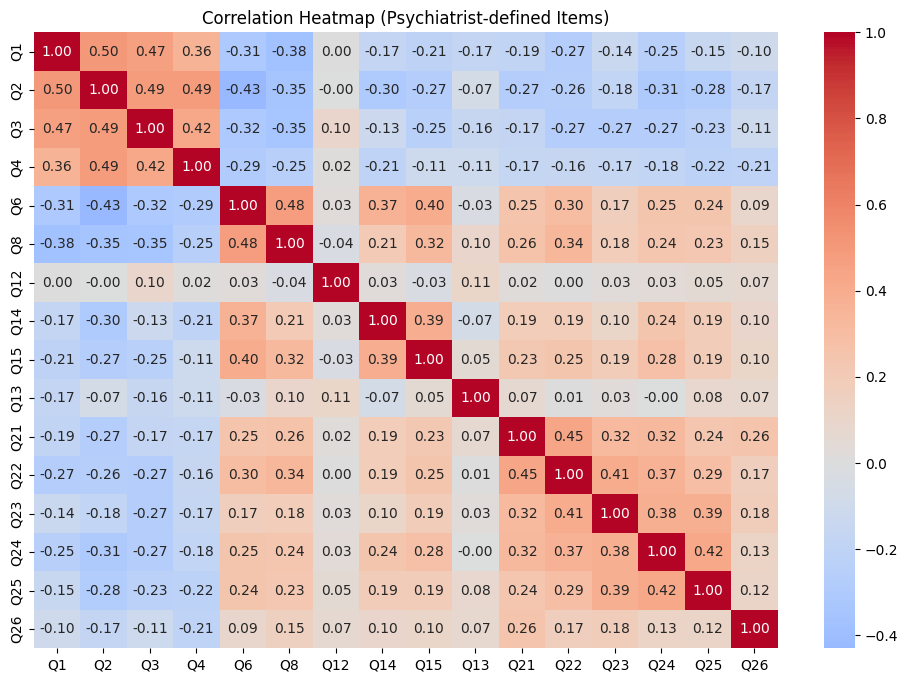

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_cols = [
    'Q1','Q2','Q3','Q4',
    'Q6','Q8','Q12','Q14','Q15','Q13',
    'Q21','Q22','Q23','Q24','Q25','Q26'
]

corr = df[selected_cols].corr(method='spearman')

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0,annot=True,fmt='.2f')
plt.title("Correlation Heatmap (Psychiatrist-defined Items)")
plt.show()

### Mood Only Relationships

<Axes: >

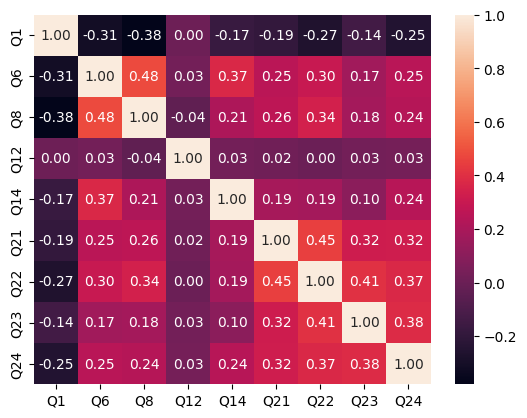

In [24]:
mood_cols = ['Q1','Q6','Q8','Q12','Q14','Q21','Q22','Q23','Q24']
sns.heatmap(df[mood_cols].corr(method='spearman'), annot=True,fmt='.2f')

<Axes: xlabel='Q6', ylabel='Q1'>

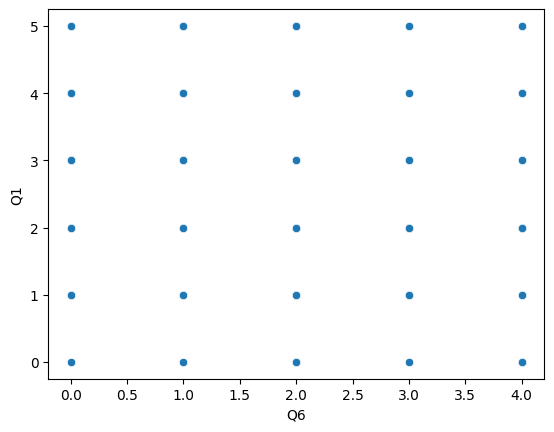

In [26]:
sns.scatterplot(x=df['Q6'], y=df['Q1'])

/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


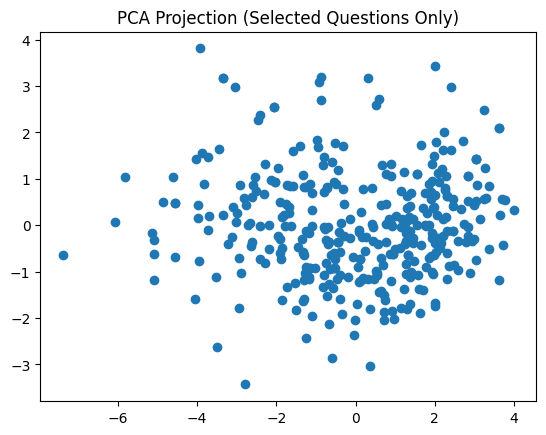

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[selected_cols]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Projection (Selected Questions Only)")
plt.show()

In [29]:
pip install factor_analyzer

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=9dc0bfe599f40d8f39bb30a88ae11e16ad486e5a5cd86accdb376b5d6f383021
  Stored in directory: /Users/anirudhiyer/Library/Caches/pip/wheels/24/59/82/6493618e30ed1cb7a013b9e1b0c9e17de80b04dfcef4ba8a4d
Successfully built factor_analyzer
Note: you may need to restart the kernel to use updated packages.


In [30]:
from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer(n_factors=4, rotation='varimax')
fa.fit(df[selected_cols])

loadings = pd.DataFrame(fa.loadings_, 
                        index=selected_cols)

print(loadings)

            0         1         2         3
Q1  -0.218428  0.581896 -0.086311 -0.211084
Q2  -0.210195  0.651950 -0.336864 -0.035614
Q3  -0.293348  0.591594 -0.055463 -0.129320
Q4  -0.129799  0.607809 -0.176235  0.080997
Q6   0.239656 -0.271976  0.538098  0.303754
Q8   0.327461 -0.301880  0.260874  0.497229
Q12  0.035903  0.003738  0.002107 -0.128361
Q14  0.134592 -0.086771  0.704444 -0.066832
Q15  0.312774 -0.109256  0.451520  0.161519
Q13  0.061532 -0.230518 -0.166980  0.051251
Q21  0.518914 -0.165873  0.140887  0.088414
Q22  0.638957 -0.121022  0.109008  0.191840
Q23  0.639454 -0.160715  0.020753 -0.098973
Q24  0.589016 -0.193364  0.199656 -0.083943
Q25  0.496725 -0.207376  0.150954 -0.117502
Q26  0.233592 -0.196880  0.056042 -0.026877


/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


<Axes: >

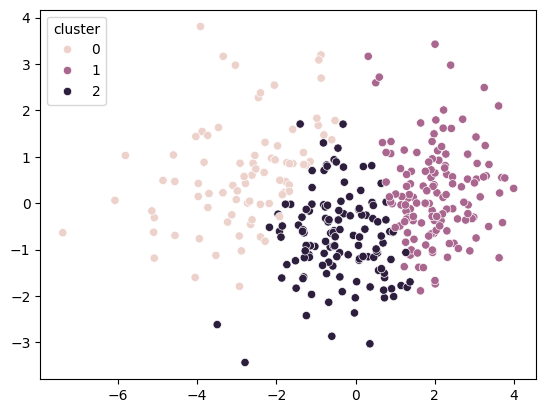

In [31]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['cluster'])

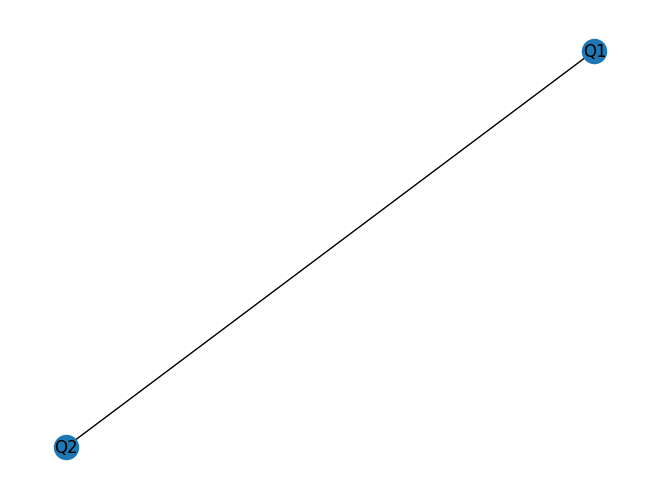

In [32]:
import networkx as nx

G = nx.Graph()

for i in selected_cols:
    for j in selected_cols:
        if i != j and abs(corr.loc[i,j]) > 0.5:
            G.add_edge(i, j)

nx.draw(G, with_labels=True)

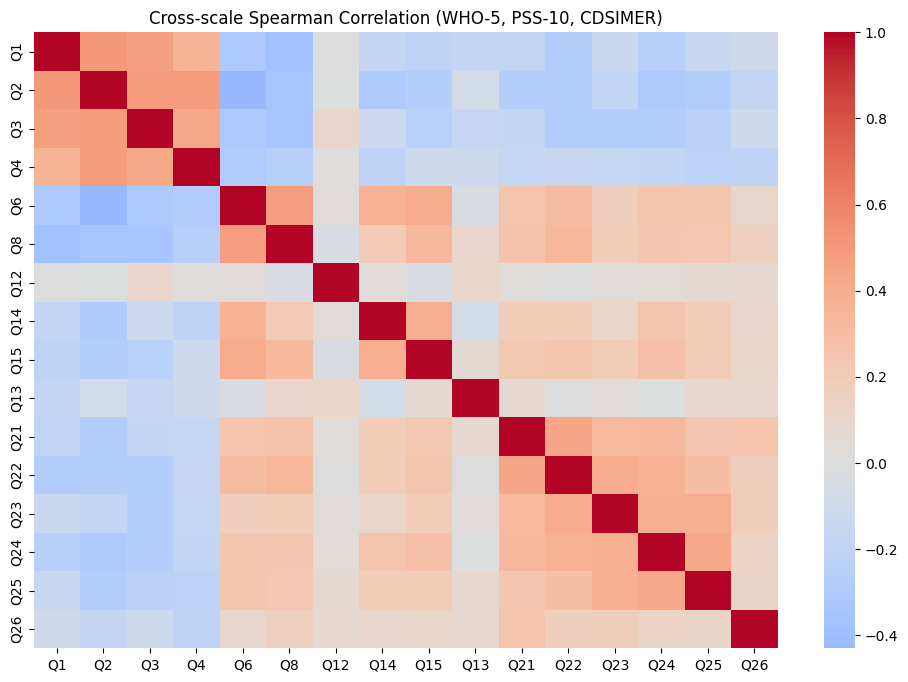

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_cols = [
    'Q1','Q2','Q3','Q4',
    'Q6','Q8','Q12','Q14','Q15','Q13',
    'Q21','Q22','Q23','Q24','Q25','Q26'
]

corr = df[selected_cols].corr(method='spearman')

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Cross-scale Spearman Correlation (WHO-5, PSS-10, CDSIMER)")
plt.show()

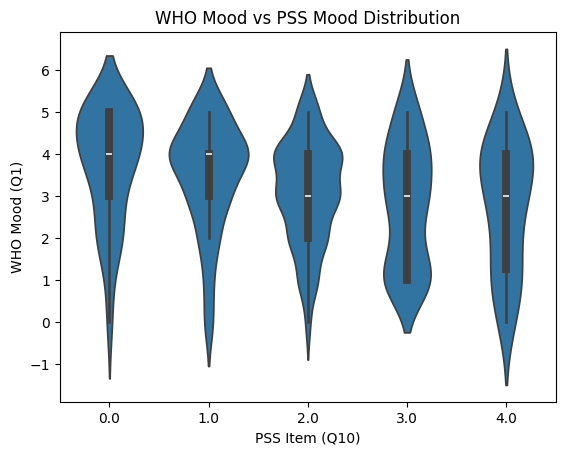

In [35]:
sns.violinplot(x='Q10', y='Q1', data=df)
plt.xlabel("PSS Item (Q10)")
plt.ylabel("WHO Mood (Q1)")
plt.title("WHO Mood vs PSS Mood Distribution")
plt.show()

In [ ]:
# Fix numeric
cd_cols = ['Q21','Q22','Q23','Q24','Q25','Q26']

for col in cd_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Correct total
df['CD_total'] = df[cd_cols].sum(axis=1)

# Create groups safely
df['CD_group'] = pd.qcut(df['CD_total'], 4, labels=False, duplicates='drop')

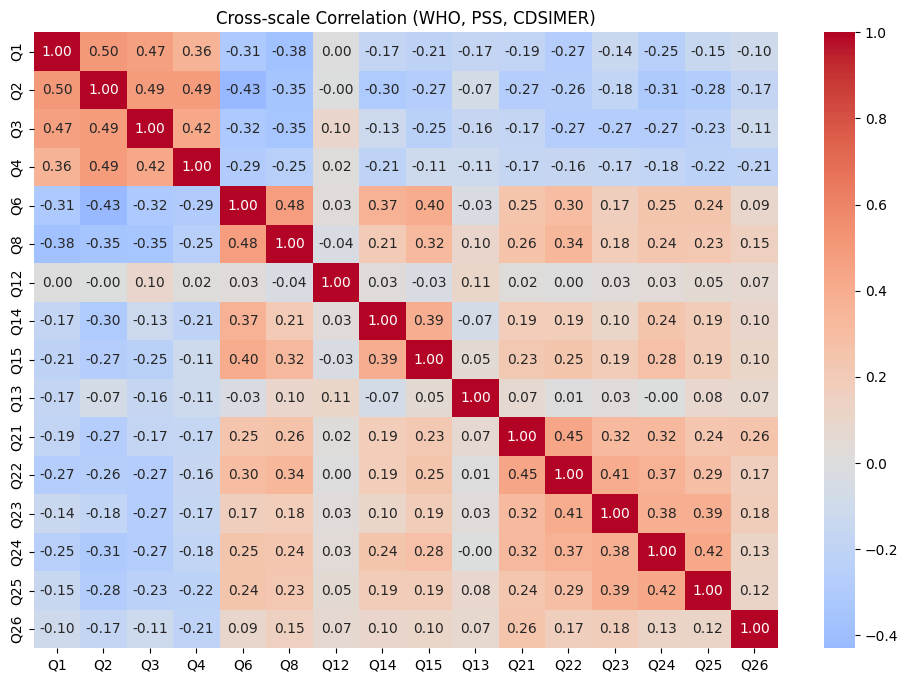

In [40]:
selected_cols = [
    'Q1','Q2','Q3','Q4',
    'Q6','Q8','Q12','Q14','Q15','Q13',
    'Q21','Q22','Q23','Q24','Q25','Q26'
]

corr = df[selected_cols].corr(method='spearman')

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0,annot=True,fmt='.2f')
plt.title("Cross-scale Correlation (WHO, PSS, CDSIMER)")
plt.show()

In [46]:
# Ensure numeric
for col in ['Q21','Q22','Q23','Q24','Q25','Q26']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Compute total
df['CD_total'] = df[['Q21','Q22','Q23','Q24','Q25','Q26']].sum(axis=1)

# Create groups safely
df['CD_group'] = pd.qcut(df['CD_total'], 4, labels=False, duplicates='drop')

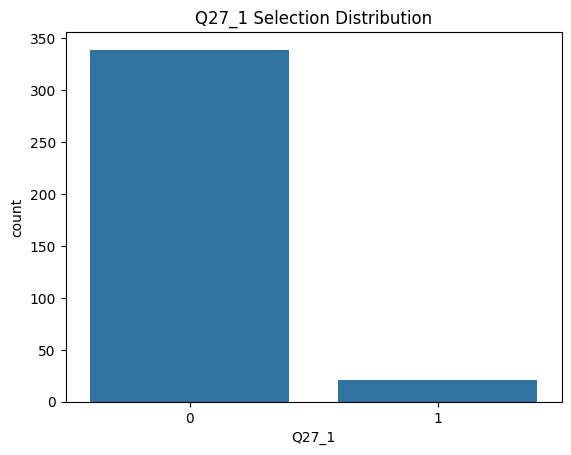

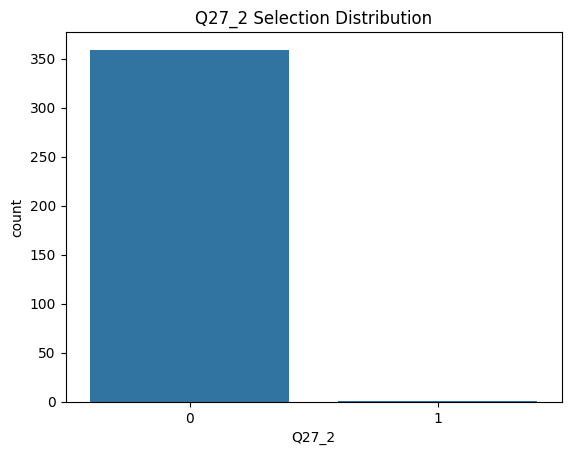

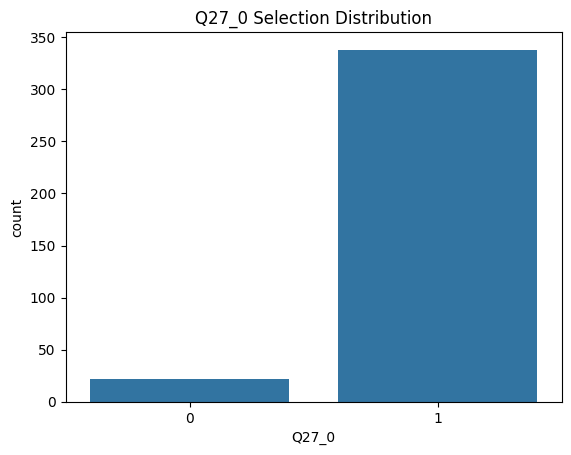

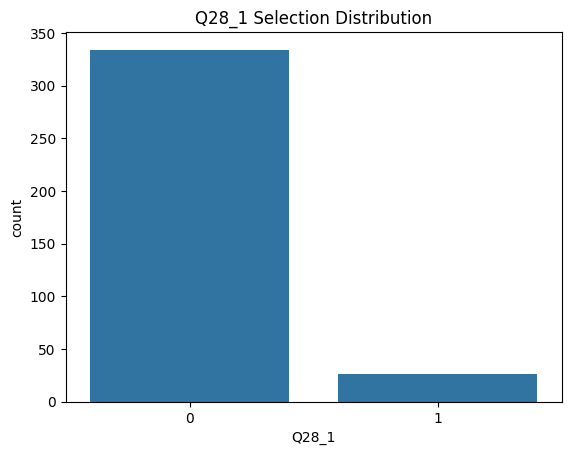

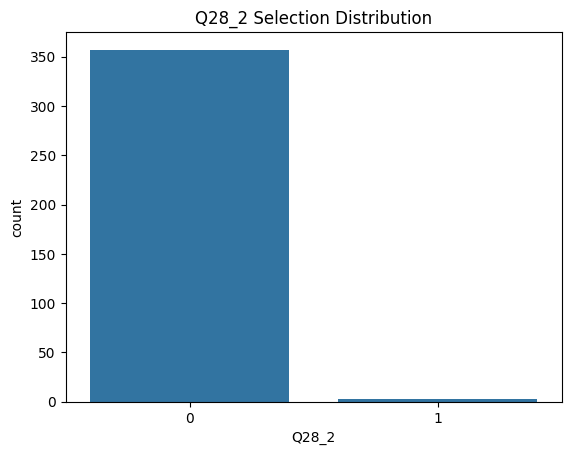

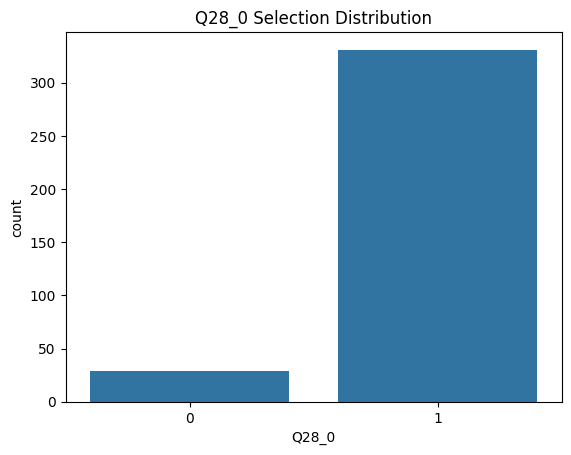

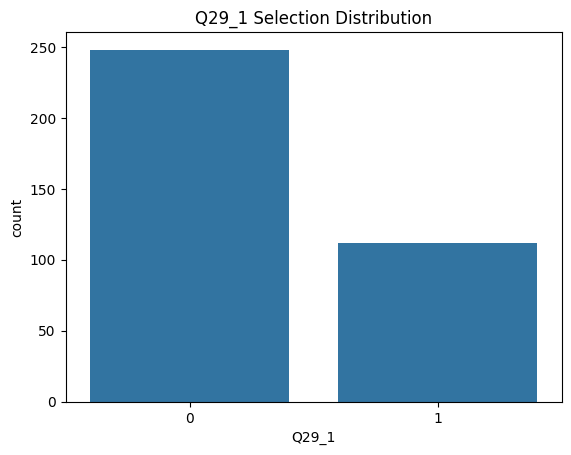

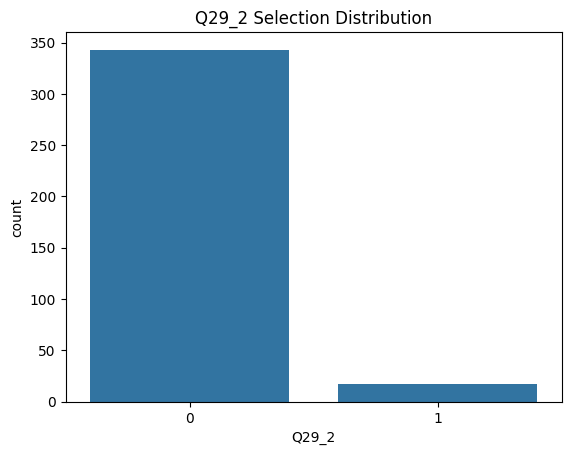

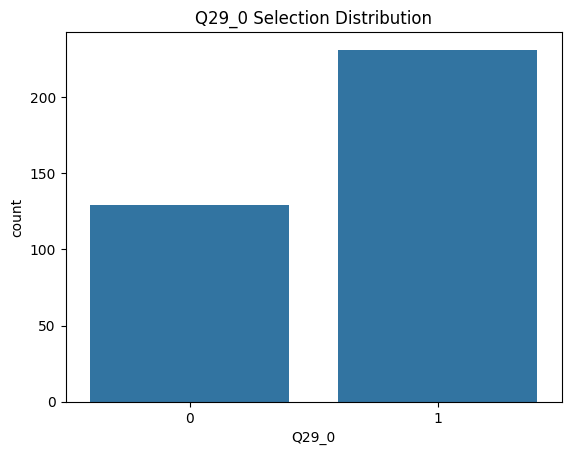

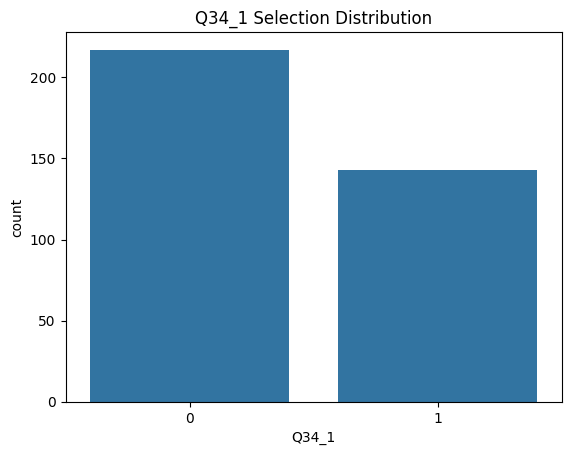

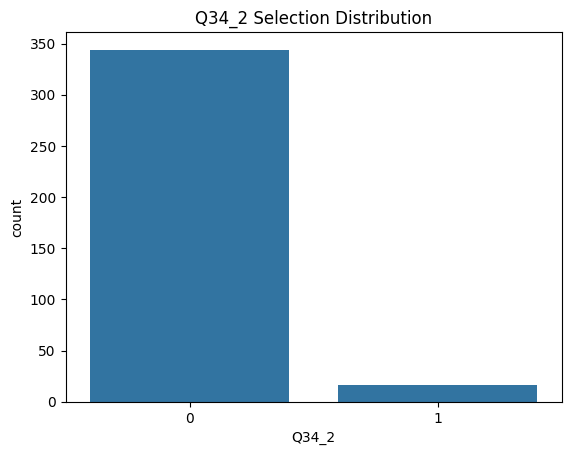

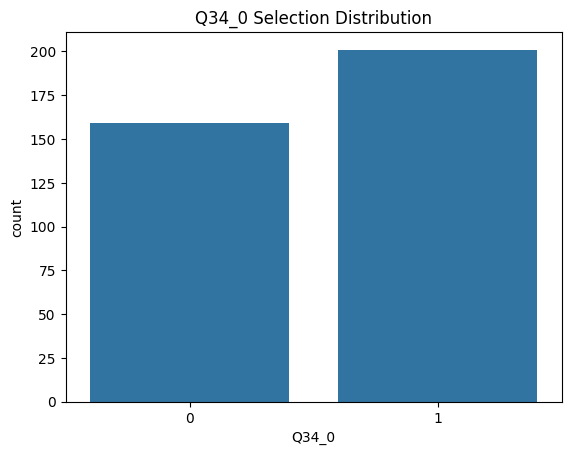

In [51]:
multi_binary_cols = [col for col in df.columns if any(q in col for q in ['Q27_','Q28_','Q29_','Q34_'])]

for col in multi_binary_cols:
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Selection Distribution")
    plt.show()

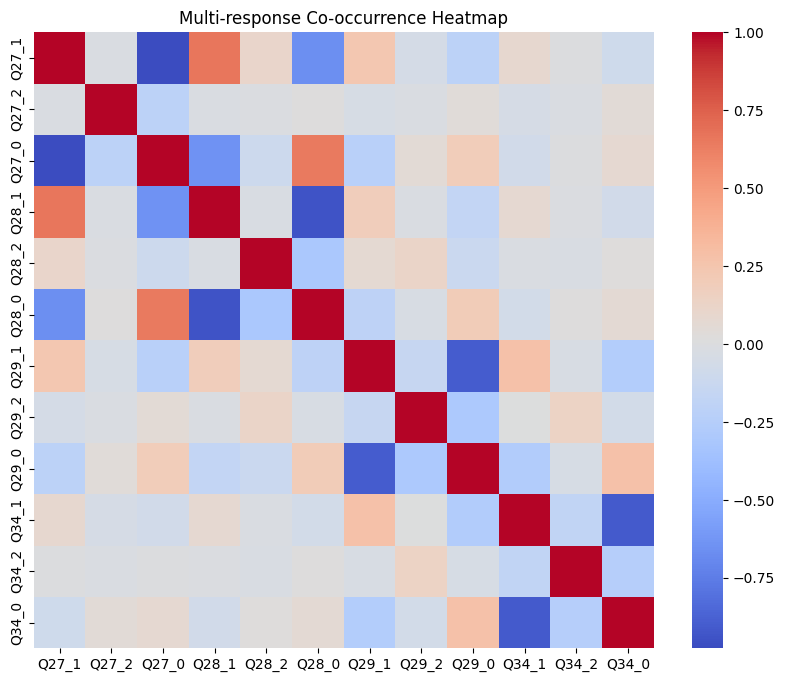

In [52]:
multi_cols_expanded = [c for c in df.columns if any(q in c for q in ['Q27_','Q28_','Q29_','Q34_'])]

plt.figure(figsize=(10,8))
sns.heatmap(df[multi_cols_expanded].corr(), cmap='coolwarm')
plt.title("Multi-response Co-occurrence Heatmap")
plt.show()